# Project : Predict GDP Growth rate of a country using regression techniques from Sklearn

This jupyter notebook is used to create linear regression model to predict the GDP Growth rate of a country using the indicators available in the Database **World Development Indicators** from Databank website. 

The following tasks are performed in the project :

1. **Business understanding**
3. **Data understanding**
3. **Data Preparation**
    1. Data required for the model is obtained from Databank website in CSV Format
    2. Handling of missing values using pandas 
    3. Linear interpolation was used to fill missing values since the data being timeseries values
    4. Minmax Scaler used to scale the values
    5. Test train split performed by grouping on categorical values and splitting on years
4. **Exploratory data analysis**
5. **Model fitting and evaluation** using sklearn
6. **Model Interpretability** using SHAPley plot

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import shap
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
%matplotlib inline

c:\Users\u22z79\Documents\privat\Udacity\Data Science Nanodegree\Coding\udacity_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Data understanding

The selected data contains the following features:

**Year** 
> Starting from 2000 till 2021

**Country**
> Developed and developing nations were chosen  

**GDP (current US$)** 
>  Gross domestic product is the total income earned through the production of goods and services in an economic territory during an accounting period. It can be measured in three different ways: using either the expenditure approach, the income approach, or the production approach. This indicator is expressed in current prices, meaning no adjustment has been made to account for price changes over time. This indicator is expressed in United States dollars.

**GDP (annual % growth)**  
> Gross domestic product is the total income earned through the production of goods and services in an economic territory during an accounting period. It can be measured in three different ways: using either the expenditure approach, the income approach, or the production approach. This indicator denotes the percentage change over each previous year of the constant price (base year 2015) series in United States dollars.

**Inflation, consumer prices (annual % growth)**  
> Inflation as measured by the consumer price index reflects the annual percentage change in the cost to the average consumer of acquiring a basket of goods and services that may be fixed or changed at specified intervals, such as yearly. This indicator denotes the percentage change over each previous year of the constant price (base year 2015) series in United States dollars.

**Gross capital formation (% of GDP)**  
> Gross capital formation includes acquisitions less disposals of produced assets for purposes of fixed capital formation, inventories or valuables. This indicator is expressed as a percentage of Gross Domestic Product (GDP) which is the total income earned through the production of goods and services in an economic territory during an accounting period.

**Life expectancy at birth, total (years)**  
> Life expectancy at birth indicates the number of years a newborn infant would live if prevailing patterns of mortality at the time of its birth were to stay the same throughout its life.

**Individuals using the Internet (% of population)**
> Internet users are individuals who have used the Internet (from any location) in the last 3 months. The Internet can be used via a computer, mobile phone, personal digital assistant, games machine, digital TV etc.

**Access to electricity (% of population)**
> Access to electricity is the percentage of population with access to electricity. Electrification data are collected from industry, national surveys and international sources.

**Exports of goods and services (% of GDP)**
> Exports of goods includes changes in the economic ownership of goods from residents of the compiling economy to non-residents, irrespective of physical movement of goods across national borders. Exports of services includes services provided by residents to non-residents. This indicator is expressed as a percentage of Gross Domestic Product (GDP) which is the total income earned through the production of goods and services in an economic territory during an accounting period.

**Domestic credit to private sector by banks (% of GDP)**
> Domestic credit to private sector by banks refers to financial resources provided to the private sector by other depository corporations (deposit taking corporations except central banks), such as through loans, purchases of nonequity securities, and trade credits and other accounts receivable, that establish a claim for repayment. For some countries these claims include credit to public enterprises. This indicator is expressed as a percentage of Gross Domestic Product (GDP) which is the total income earned through the production of goods and services in an economic territory during an accounting period.

In [2]:
df_raw = pd.read_csv("C:/Users/u22z79/Documents/privat/Udacity/Data Science Nanodegree/Coding/Projectwork_introduction_to_datascience_and_supervisedML/sample4.csv")
df_raw.head()

,Time,Time Code,Country Name,Country Code,GDP (current US$) [NY.GDP.MKTP.CD],GDP growth (annual %) [NY.GDP.MKTP.KD.ZG],"Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]",Gross capital formation (% of GDP) [NE.GDI.TOTL.ZS],"Life expectancy at birth, total (years) [SP.DYN.LE00.IN]",Individuals using the Internet (% of population) [IT.NET.USER.ZS],Access to electricity (% of population) [EG.ELC.ACCS.ZS],Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS],Domestic credit to private sector by banks (% of GDP) [FD.AST.PRVT.GD.ZS]
0,2000,YR2000,Germany,DEU,1.966981e+12,2.877246,1.4402683871974,23.9639660790924,77.926829,30.2163,100.0,29.6806532498145,..
1,2000,YR2000,India,IND,4.683955e+11,3.840991,4.00943591045191,25.677316683955,62.749000,0.527532,60.3,12.9972363113479,28.3395511575183
2,2000,YR2000,Australia,AUS,4.161678e+11,3.921503,4.45743514797223,26.2504640290701,79.234146,46.7561,100.0,19.3902280759468,87.5351786851453
3,2000,YR2000,Austria,AUT,1.961816e+11,3.189523,2.34486285357281,25.9400787116929,78.126829,33.7301,100.0,43.591091462861,..
4,2000,YR2000,Belgium,BEL,2.367925e+11,3.716705,2.54451776190909,23.7829613022103,77.721951,29.4317,100.0,72.5473951580567,..


# 3. Data Preparation

In [3]:
df_raw.isna().sum()

Time                                                                         3
Time Code                                                                    5
Country Name                                                                 5
Country Code                                                                 5
GDP (current US$) [NY.GDP.MKTP.CD]                                           5
GDP growth (annual %) [NY.GDP.MKTP.KD.ZG]                                    5
Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]                       5
Gross capital formation (% of GDP) [NE.GDI.TOTL.ZS]                          5
Life expectancy at birth, total (years) [SP.DYN.LE00.IN]                     5
Individuals using the Internet (% of population) [IT.NET.USER.ZS]            5
Access to electricity (% of population) [EG.ELC.ACCS.ZS]                     5
Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS]                    5
Domestic credit to private sector by banks (% of GDP

In [4]:
df_raw[df_raw.isna().any(axis=1)]

,Time,Time Code,Country Name,Country Code,GDP (current US$) [NY.GDP.MKTP.CD],GDP growth (annual %) [NY.GDP.MKTP.KD.ZG],"Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]",Gross capital formation (% of GDP) [NE.GDI.TOTL.ZS],"Life expectancy at birth, total (years) [SP.DYN.LE00.IN]",Individuals using the Internet (% of population) [IT.NET.USER.ZS],Access to electricity (% of population) [EG.ELC.ACCS.ZS],Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS],Domestic credit to private sector by banks (% of GDP) [FD.AST.PRVT.GD.ZS]
792,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
794,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
795,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
796,Last Updated: 10/07/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_raw.dtypes

Time                                                                          object
Time Code                                                                     object
Country Name                                                                  object
Country Code                                                                  object
GDP (current US$) [NY.GDP.MKTP.CD]                                           float64
GDP growth (annual %) [NY.GDP.MKTP.KD.ZG]                                    float64
Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]                        object
Gross capital formation (% of GDP) [NE.GDI.TOTL.ZS]                           object
Life expectancy at birth, total (years) [SP.DYN.LE00.IN]                     float64
Individuals using the Internet (% of population) [IT.NET.USER.ZS]             object
Access to electricity (% of population) [EG.ELC.ACCS.ZS]                     float64
Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS]        

In [6]:
# Clean missing values 
# NaN values were dropped
df = df_raw.dropna()

In [7]:
#Shape before dropping values
df_raw.shape

(797, 13)

In [8]:
#Shape after dropping values
df.shape

(792, 13)

In [9]:
#Additionally there were values with .. (double dots). These values are empty so were replaced with NaN
df = df.replace("..", pd.NA)

**Time code and Country code** categorical Columns are either redundant or not required for the model. Subsequently these columns were dropped from the original dataset. One more thing carried out in the upcoming code block was to convert the numerical columns to float. In the original dataset, they were interpredted as strings. 

In [10]:
# Keeping only the relevant columns needed for the model
columns_to_keep = ['Country Name', 'Time', 
                   'GDP (current US$) [NY.GDP.MKTP.CD]',
                   'GDP growth (annual %) [NY.GDP.MKTP.KD.ZG]',
                   'Domestic credit to private sector by banks (% of GDP) [FD.AST.PRVT.GD.ZS]',
                   'Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]',
                   'Gross capital formation (% of GDP) [NE.GDI.TOTL.ZS]',
                   'Life expectancy at birth, total (years) [SP.DYN.LE00.IN]',
                   'Individuals using the Internet (% of population) [IT.NET.USER.ZS]',
                   'Access to electricity (% of population) [EG.ELC.ACCS.ZS]',
                   'Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS]']

df = df[columns_to_keep]

# Renaming columns for my convenience
df = df.rename(columns={
    'Country Name':'Country',
    'Time':'Year',
    'GDP (current US$) [NY.GDP.MKTP.CD]':'GDP (current US$)',
    'Domestic credit to private sector by banks (% of GDP) [FD.AST.PRVT.GD.ZS]':'Domestic credit to private sector by banks (% of GDP)',
    'GDP growth (annual %) [NY.GDP.MKTP.KD.ZG]':'GDP growth (annual %)',
    'Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]':'Inflation, consumer prices (annual %)',
    'Gross capital formation (% of GDP) [NE.GDI.TOTL.ZS]':'Gross capital formation (% of GDP)',
    'Life expectancy at birth, total (years) [SP.DYN.LE00.IN]':'Life expectancy at birth, total (years)',
    'Individuals using the Internet (% of population) [IT.NET.USER.ZS]':'Individuals using the Internet (% of population)',
    'Access to electricity (% of population) [EG.ELC.ACCS.ZS]':'Access to electricity (% of population)',
    'Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS]':'Exports of goods and services (% of GDP)'
})

# Column Year is set as integer
df['Year'] = df['Year'].astype(int)
df['Domestic credit to private sector by banks (% of GDP)'] = df['Domestic credit to private sector by banks (% of GDP)'].apply(pd.to_numeric, errors='coerce')
df['GDP growth (annual %)'] = df['GDP growth (annual %)'].apply(pd.to_numeric, errors='coerce')
df['Inflation, consumer prices (annual %)'] = df['Inflation, consumer prices (annual %)'].apply(pd.to_numeric, errors='coerce')
df['Gross capital formation (% of GDP)'] = df['Gross capital formation (% of GDP)'].apply(pd.to_numeric, errors='coerce')
df['Individuals using the Internet (% of population)'] = df['Individuals using the Internet (% of population)'].apply(pd.to_numeric, errors='coerce')
df['Access to electricity (% of population)'] = df['Access to electricity (% of population)'].apply(pd.to_numeric, errors='coerce')
df['Exports of goods and services (% of GDP)'] = df['Exports of goods and services (% of GDP)'].apply(pd.to_numeric, errors='coerce')

# Sort by Country and Year
df = df.sort_values(by=['Country','Year']).reset_index(drop=True)

# Resulting dataset
df.head()

,Country,Year,GDP (current US$),GDP growth (annual %),Domestic credit to private sector by banks (% of GDP),"Inflation, consumer prices (annual %)",Gross capital formation (% of GDP),"Life expectancy at birth, total (years)",Individuals using the Internet (% of population),Access to electricity (% of population),Exports of goods and services (% of GDP)
0,Australia,2000,4.161678e+11,3.921503,87.535179,4.457435,26.250464,79.234146,46.7561,100.0,19.390228
1,Australia,2001,3.796293e+11,2.025106,88.359079,4.407135,23.393064,79.634146,52.6893,100.0,22.152326
2,Australia,2002,3.957887e+11,3.979586,91.217703,2.981575,24.407426,79.936585,NaN,100.0,20.726661
3,Australia,2003,4.677391e+11,3.090762,99.134711,2.732596,25.936985,80.239024,NaN,100.0,19.057213
4,Australia,2004,6.146600e+11,4.224285,102.611546,2.343255,27.063647,80.490244,NaN,100.0,17.162468


In [11]:
df.dtypes

Country                                                   object
Year                                                       int32
GDP (current US$)                                        float64
GDP growth (annual %)                                    float64
Domestic credit to private sector by banks (% of GDP)    float64
Inflation, consumer prices (annual %)                    float64
Gross capital formation (% of GDP)                       float64
Life expectancy at birth, total (years)                  float64
Individuals using the Internet (% of population)         float64
Access to electricity (% of population)                  float64
Exports of goods and services (% of GDP)                 float64
dtype: object

In [12]:
df.shape

(792, 11)

In [13]:
df[df.Country == "Australia"]

,Country,Year,GDP (current US$),GDP growth (annual %),Domestic credit to private sector by banks (% of GDP),"Inflation, consumer prices (annual %)",Gross capital formation (% of GDP),"Life expectancy at birth, total (years)",Individuals using the Internet (% of population),Access to electricity (% of population),Exports of goods and services (% of GDP)
0,Australia,2000,4.161678e+11,3.921503,87.535179,4.457435,26.250464,79.234146,46.7561,100.0,19.390228
1,Australia,2001,3.796293e+11,2.025106,88.359079,4.407135,23.393064,79.634146,52.6893,100.0,22.152326
2,Australia,2002,3.957887e+11,3.979586,91.217703,2.981575,24.407426,79.936585,NaN,100.0,20.726661
3,Australia,2003,4.677391e+11,3.090762,99.134711,2.732596,25.936985,80.239024,NaN,100.0,19.057213
4,Australia,2004,6.146600e+11,4.224285,102.611546,2.343255,27.063647,80.490244,NaN,100.0,17.162468
5,Australia,2005,6.956929e+11,3.154168,108.433078,2.691832,27.456826,80.841463,63.0000,100.0,18.224373
6,Australia,2006,7.484176e+11,2.755346,113.601510,3.555288,27.504814,81.041463,66.0000,100.0,19.853539
7,Australia,2007,8.550075e+11,3.773322,120.511803,2.327611,27.501990,81.292683,69.4500,100.0,20.183504
8,Australia,2008,1.056112e+12,3.586267,121.713420,4.350299,28.603315,81.395122,71.6700,100.0,20.148877
9,Australia,2009,9.287621e+11,1.892556,122.507455,1.771117,27.364340,81.543902,74.2500,100.0,23.010985


In [14]:
df.isna().sum()

Country                                                   0
Year                                                      0
GDP (current US$)                                         0
GDP growth (annual %)                                     0
Domestic credit to private sector by banks (% of GDP)    26
Inflation, consumer prices (annual %)                    41
Gross capital formation (% of GDP)                        1
Life expectancy at birth, total (years)                   0
Individuals using the Internet (% of population)          4
Access to electricity (% of population)                   0
Exports of goods and services (% of GDP)                  1
dtype: int64

In [15]:
# Set pandas to display all rows
pd.set_option('display.max_rows', None)

# Show all columns
pd.set_option('display.max_columns', None)

In [16]:
#List all the rows with NaN values
df[df.isna().any(axis=1)]

,Country,Year,GDP (current US$),GDP growth (annual %),Domestic credit to private sector by banks (% of GDP),"Inflation, consumer prices (annual %)",Gross capital formation (% of GDP),"Life expectancy at birth, total (years)",Individuals using the Internet (% of population),Access to electricity (% of population),Exports of goods and services (% of GDP)
2,Australia,2002,3.957887e+11,3.979586,91.217703,2.981575,24.407426,79.936585,NaN,100.0,20.726661
3,Australia,2003,4.677391e+11,3.090762,99.134711,2.732596,25.936985,80.239024,NaN,100.0,19.057213
4,Australia,2004,6.146600e+11,4.224285,102.611546,2.343255,27.063647,80.490244,NaN,100.0,17.162468
22,Austria,2000,1.961816e+11,3.189523,NaN,2.344863,25.940079,78.126829,33.730100,100.0,43.591091
44,Belgium,2000,2.367925e+11,3.716705,NaN,2.544518,23.782961,77.721951,29.431700,100.0,72.547395
132,Germany,2000,1.966981e+12,2.877246,NaN,1.440268,23.963966,77.926829,30.216300,100.0,29.680653
175,India,2021,3.167271e+12,9.689592,50.142158,5.131407,32.115822,67.282000,NaN,99.6,21.399158
198,Ireland,2000,1.002076e+11,9.403525,NaN,5.577633,24.507951,76.536585,17.850500,100.0,94.389458
242,Italy,2000,1.149661e+12,3.882099,NaN,2.537685,21.323610,79.778049,23.110900,100.0,25.561196
308,Luxembourg,2000,2.123018e+10,6.938130,NaN,3.150767,22.559144,77.873171,22.887300,100.0,147.644884


For the model fitting, the features were split into dependent and independent ones. According to the business requirement, we need to predict the GDP growth rate of a company based on the economic, social and infrastructure indicators. The target feature **GDP growth (annual %)** is assigned to y and the remaining features to X dataframe.

In [17]:
X = df.drop({'GDP growth (annual %)'},axis=1)
y = df['GDP growth (annual %)']

In [18]:
X.dtypes

Country                                                   object
Year                                                       int32
GDP (current US$)                                        float64
Domestic credit to private sector by banks (% of GDP)    float64
Inflation, consumer prices (annual %)                    float64
Gross capital formation (% of GDP)                       float64
Life expectancy at birth, total (years)                  float64
Individuals using the Internet (% of population)         float64
Access to electricity (% of population)                  float64
Exports of goods and services (% of GDP)                 float64
dtype: object

By observing the missing values in the above cells, instead of imputing with average, median or nearest neighbour values basic linear interpolation was used. The values before and after the missing values seem to linearly increase for the features **Individuals using the Internet (% of population)** , **Domestic credit to private sector by banks (% of GDP)** and **Inflation, consumer prices (annual %)**. Considering this assumption, linear interpolation seemed to be a better option. 

In [19]:
X_interpolated = X.interpolate(method='nearest',limit_direction='both',axis=0)

C:\Users\u22z79\AppData\Local\Temp\ipykernel_20116\3453653841.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  X_interpolated = X.interpolate(method='nearest',limit_direction='both',axis=0)


In [20]:
X_interpolated[X_interpolated.isnull().any(axis=1)]

,Country,Year,GDP (current US$),Domestic credit to private sector by banks (% of GDP),"Inflation, consumer prices (annual %)",Gross capital formation (% of GDP),"Life expectancy at birth, total (years)",Individuals using the Internet (% of population),Access to electricity (% of population),Exports of goods and services (% of GDP)


In [21]:
X_interpolated[X_interpolated.Country == "Australia"]

,Country,Year,GDP (current US$),Domestic credit to private sector by banks (% of GDP),"Inflation, consumer prices (annual %)",Gross capital formation (% of GDP),"Life expectancy at birth, total (years)",Individuals using the Internet (% of population),Access to electricity (% of population),Exports of goods and services (% of GDP)
0,Australia,2000,4.161678e+11,87.535179,4.457435,26.250464,79.234146,46.7561,100.0,19.390228
1,Australia,2001,3.796293e+11,88.359079,4.407135,23.393064,79.634146,52.6893,100.0,22.152326
2,Australia,2002,3.957887e+11,91.217703,2.981575,24.407426,79.936585,52.6893,100.0,20.726661
3,Australia,2003,4.677391e+11,99.134711,2.732596,25.936985,80.239024,52.6893,100.0,19.057213
4,Australia,2004,6.146600e+11,102.611546,2.343255,27.063647,80.490244,63.0000,100.0,17.162468
5,Australia,2005,6.956929e+11,108.433078,2.691832,27.456826,80.841463,63.0000,100.0,18.224373
6,Australia,2006,7.484176e+11,113.601510,3.555288,27.504814,81.041463,66.0000,100.0,19.853539
7,Australia,2007,8.550075e+11,120.511803,2.327611,27.501990,81.292683,69.4500,100.0,20.183504
8,Australia,2008,1.056112e+12,121.713420,4.350299,28.603315,81.395122,71.6700,100.0,20.148877
9,Australia,2009,9.287621e+11,122.507455,1.771117,27.364340,81.543902,74.2500,100.0,23.010985


In [22]:
X_interpolated.isna().sum()

Country                                                  0
Year                                                     0
GDP (current US$)                                        0
Domestic credit to private sector by banks (% of GDP)    0
Inflation, consumer prices (annual %)                    0
Gross capital formation (% of GDP)                       0
Life expectancy at birth, total (years)                  0
Individuals using the Internet (% of population)         0
Access to electricity (% of population)                  0
Exports of goods and services (% of GDP)                 0
dtype: int64

In [23]:
y.isna().sum()

0

In [24]:
#combing the dataframes again for plotting purposes
new_df = pd.concat([X_interpolated,y],axis=1)

In [25]:
new_df.head()

,Country,Year,GDP (current US$),Domestic credit to private sector by banks (% of GDP),"Inflation, consumer prices (annual %)",Gross capital formation (% of GDP),"Life expectancy at birth, total (years)",Individuals using the Internet (% of population),Access to electricity (% of population),Exports of goods and services (% of GDP),GDP growth (annual %)
0,Australia,2000,4.161678e+11,87.535179,4.457435,26.250464,79.234146,46.7561,100.0,19.390228,3.921503
1,Australia,2001,3.796293e+11,88.359079,4.407135,23.393064,79.634146,52.6893,100.0,22.152326,2.025106
2,Australia,2002,3.957887e+11,91.217703,2.981575,24.407426,79.936585,52.6893,100.0,20.726661,3.979586
3,Australia,2003,4.677391e+11,99.134711,2.732596,25.936985,80.239024,52.6893,100.0,19.057213,3.090762
4,Australia,2004,6.146600e+11,102.611546,2.343255,27.063647,80.490244,63.0000,100.0,17.162468,4.224285


# 4. Exploratory data analysis

As far as bin size is concerned, There can be many ways to choose the size of bins, but one of them is Sturge’s rule which is,

K = 1 + 3.22 logN

where,  
K is the number of bins  
N is the number of observations

In [26]:
import math
k = 1 + 3.22 * math.log10(len(y))
k

10.33389508471817

## 4.1 Histogram Interpretation

**GDP (current US$)** : Left-Skewed distribution which implies that certain countries (US, China, Germany, Japan, India) contribute significantly more than many countries to the distribution to be skewed

**Access to electricity (% of population)** and **Life expectancy at birth, total (years)** : Right-Skewed distribution shows that high percentage of population has access to electricity and life expectancy has increased over the years with the advancement in medicin industry

**GDP growth (annual %)** and **Gross capital formation (% of GDP)** : Can be interpreted as normal distribution curves. Distribution of both features suggest that many countries over the years are investing capital on itself and there is steady GDP growth around 0-5%


array([[<Axes: title={'center': 'GDP (current US$)'}>,
        <Axes: title={'center': 'Domestic credit to private sector by banks (% of GDP)'}>,
        <Axes: title={'center': 'Inflation, consumer prices (annual %)'}>],
       [<Axes: title={'center': 'Gross capital formation (% of GDP)'}>,
        <Axes: title={'center': 'Life expectancy at birth, total (years)'}>,
        <Axes: title={'center': 'Individuals using the Internet (% of population)'}>],
       [<Axes: title={'center': 'Access to electricity (% of population)'}>,
        <Axes: title={'center': 'Exports of goods and services (% of GDP)'}>,
        <Axes: title={'center': 'GDP growth (annual %)'}>]], dtype=object)

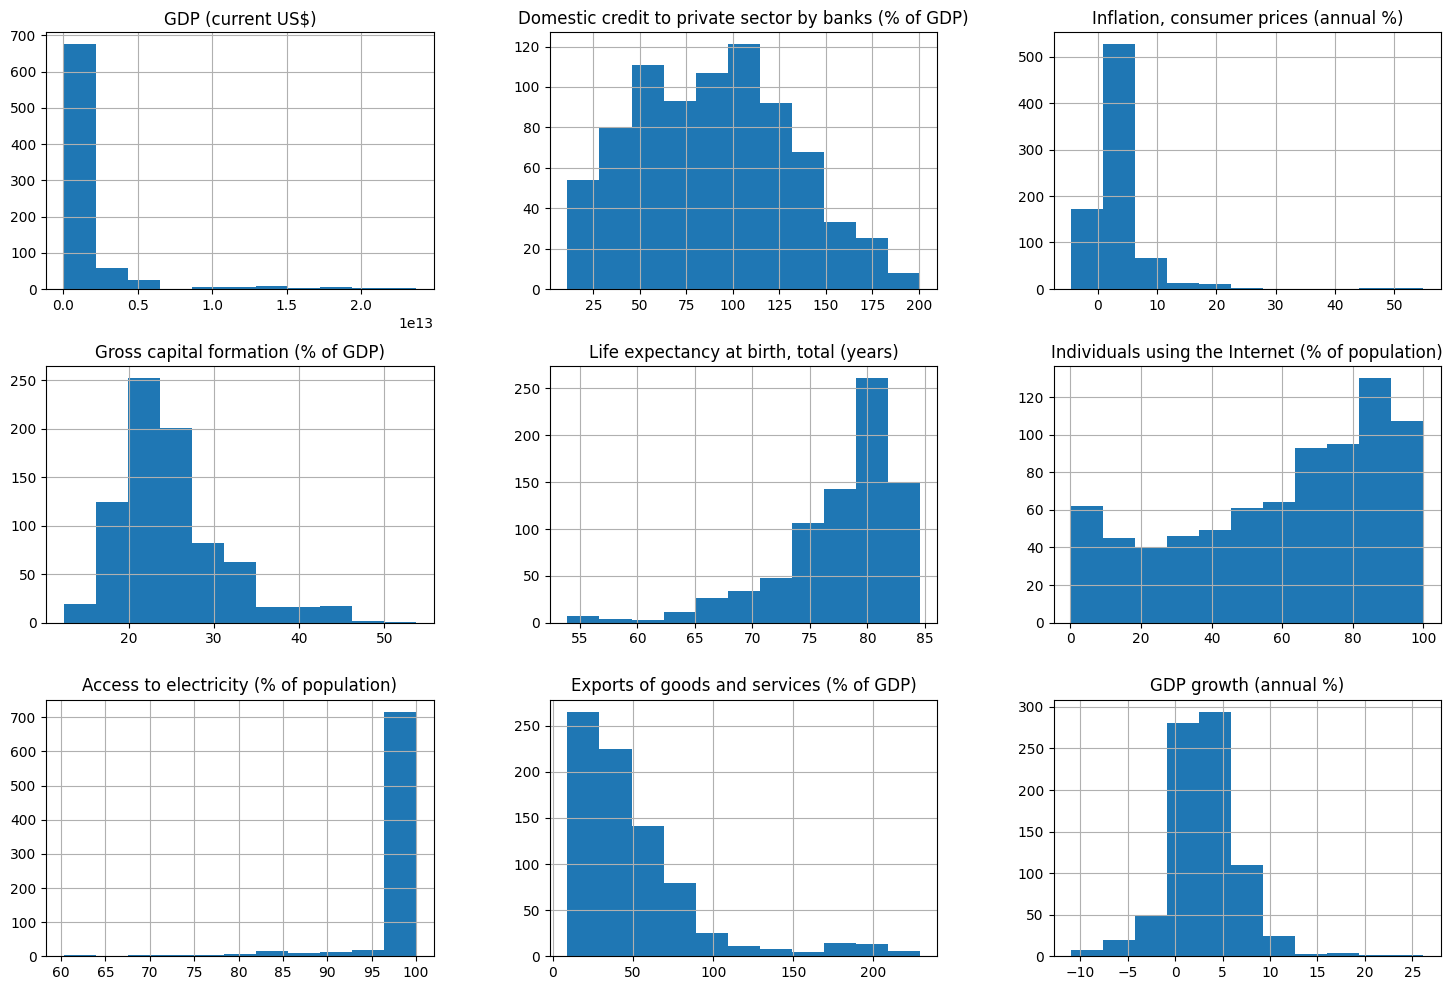

In [27]:
#Chossing bin size based on Sturge's rule
new_df.drop(columns=['Country', 'Year']).hist(bins=11, figsize=(18, 12))

## 4.2 Trend graphs 

After having visualized the histograms, a trend plot country-wise for feature pairs shows the correlation between them. Comparing the gross capital formation and gdp growth shows that they are closely correlated. Whenever there is an decrease in Gross capital formation we observe a dip in GDP growth rate. 

In [28]:
def create_trend_plot_for_country(plot_df,country_name,feature1,feature2):
    # Create the plot with two y-axes
    fig, ax1 = plt.subplots()
    
    # Plot GDP Growth on the primary y-axis
    line1 = sns.lineplot(data=plot_df[plot_df["Country"]==country_name], x='Year', y=feature1, ax=ax1, label=feature1, color='blue',legend=False)
    ax1.set_ylabel(feature1, color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    # Create a secondary y-axis
    ax2 = ax1.twinx()
    
    # Plot Inflation on the secondary y-axis
    line2 = sns.lineplot(data=plot_df[plot_df["Country"]==country_name], x='Year', y=feature2, ax=ax2, label=feature2, color='red',legend=False)
    ax2.set_ylabel(feature2, color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    # Combine legends from both axes
    lines = line1.lines + line2.lines
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc='upper right', bbox_to_anchor=(1.75,1))
    
    # Add title and show the plot
    plt.suptitle(f"{feature1} vs {feature2} for {country_name} between 2000 and 2021",wrap = True)
    plt.show()


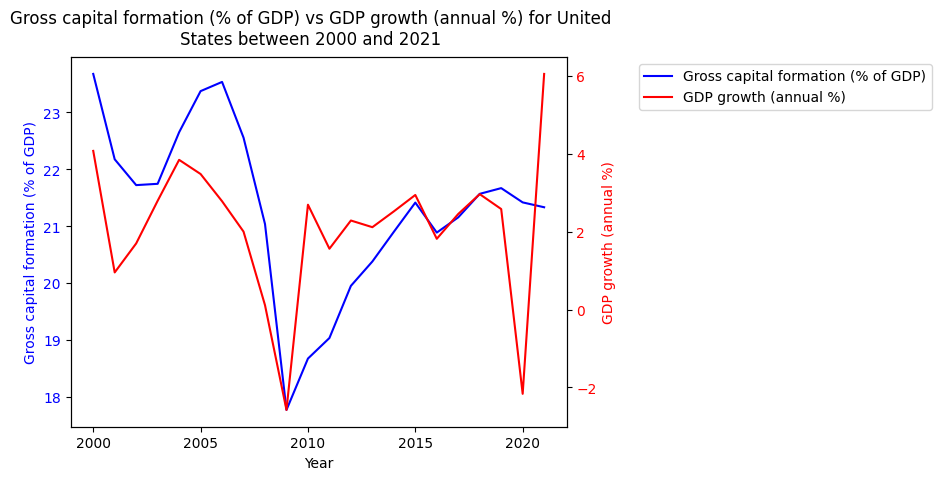

In [29]:
create_trend_plot_for_country(new_df,"United States","Gross capital formation (% of GDP)","GDP growth (annual %)")

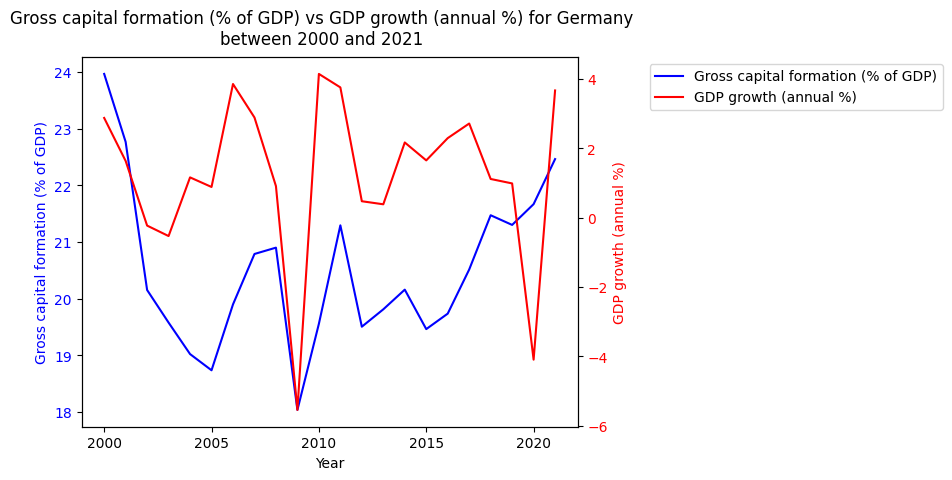

In [30]:
create_trend_plot_for_country(new_df,"Germany","Gross capital formation (% of GDP)","GDP growth (annual %)")

India on the other hand seems to follow the rule most of the time. But the correlation takes a hit between 2013 and 2018. There seems to be a steady GDP growth against a falling GCP. One reason could be the political scenes during that period. A Stable government was formed in 2014 and continued till 2019 except for Covid in 2020. 

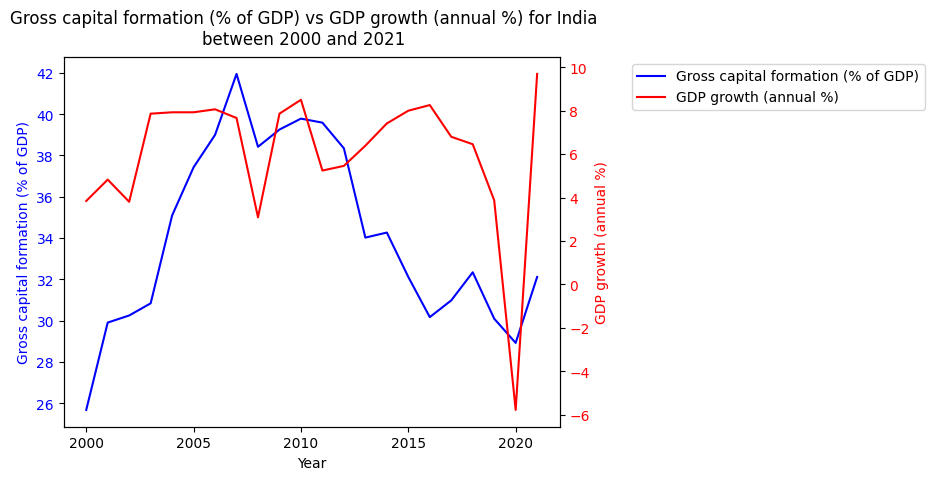

In [31]:
create_trend_plot_for_country(new_df,"India","Gross capital formation (% of GDP)","GDP growth (annual %)")

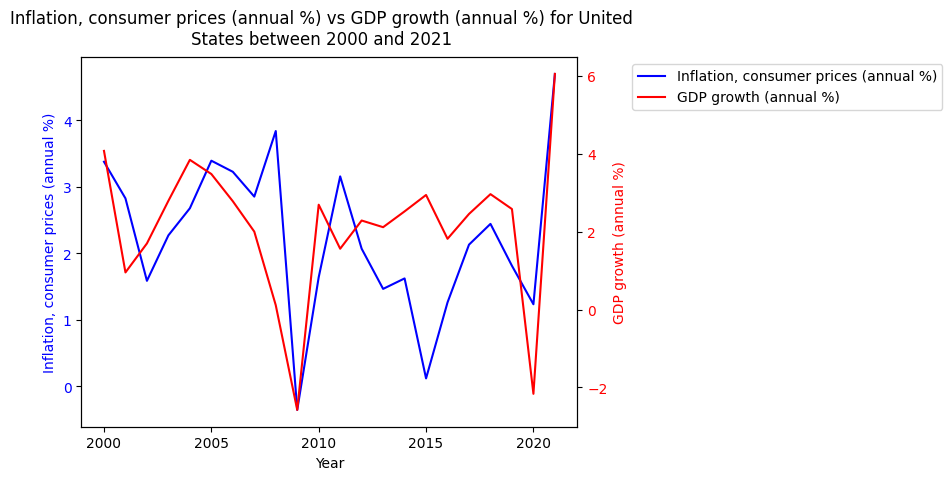

In [32]:
create_trend_plot_for_country(new_df,"United States","Inflation, consumer prices (annual %)","GDP growth (annual %)")

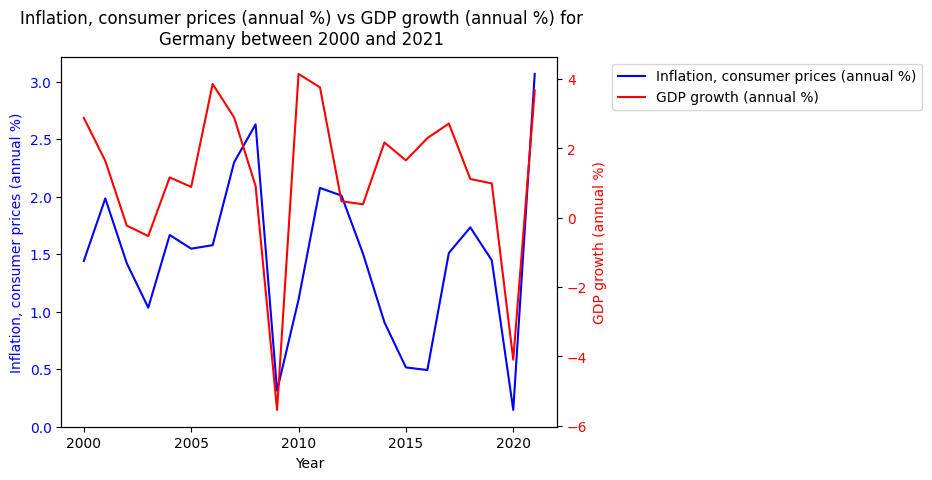

In [33]:
create_trend_plot_for_country(new_df,"Germany","Inflation, consumer prices (annual %)","GDP growth (annual %)")

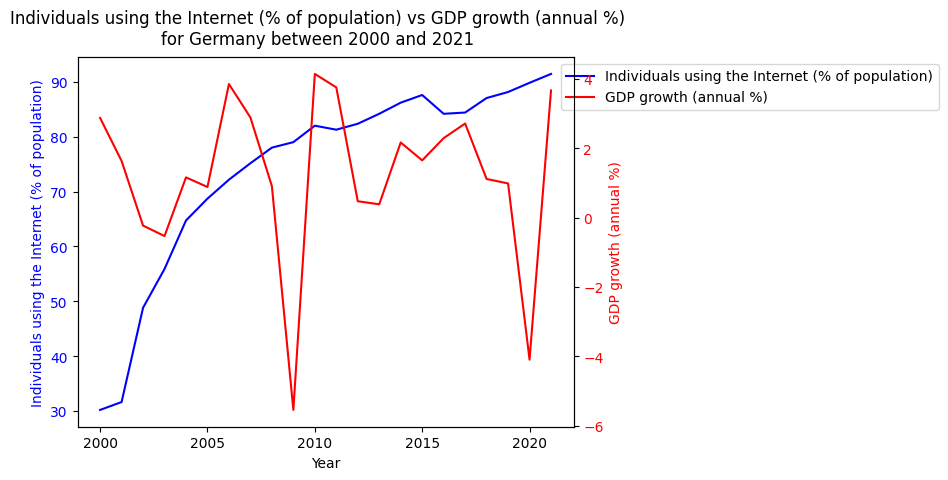

In [34]:
create_trend_plot_for_country(new_df,"Germany","Individuals using the Internet (% of population)","GDP growth (annual %)")

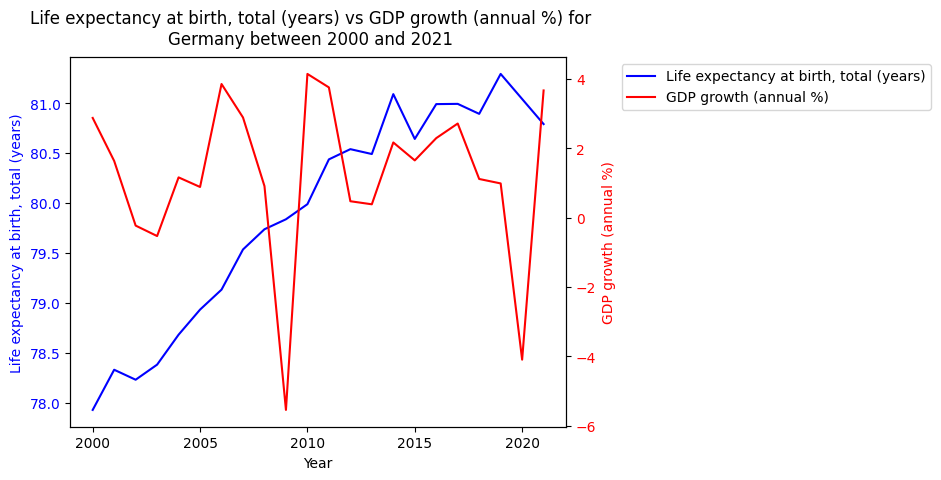

In [35]:
create_trend_plot_for_country(new_df,"Germany","Life expectancy at birth, total (years)","GDP growth (annual %)")

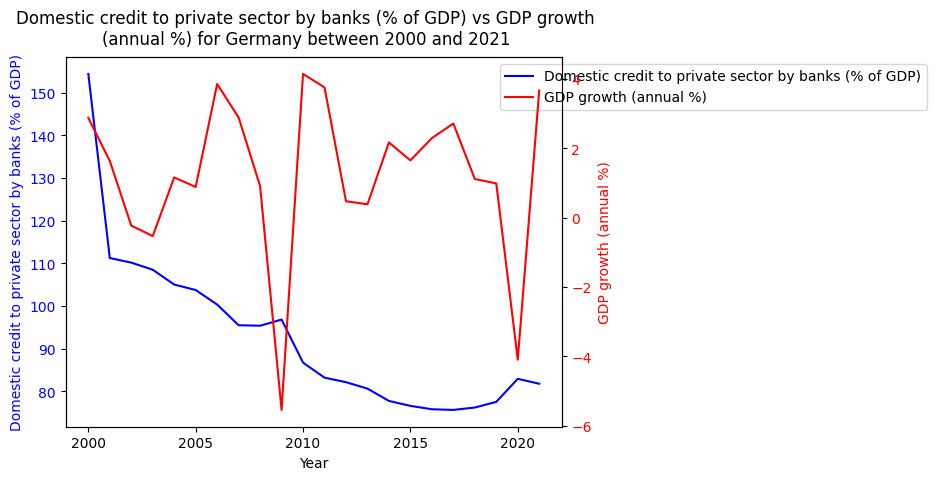

In [36]:
create_trend_plot_for_country(new_df,"Germany","Domestic credit to private sector by banks (% of GDP)","GDP growth (annual %)")

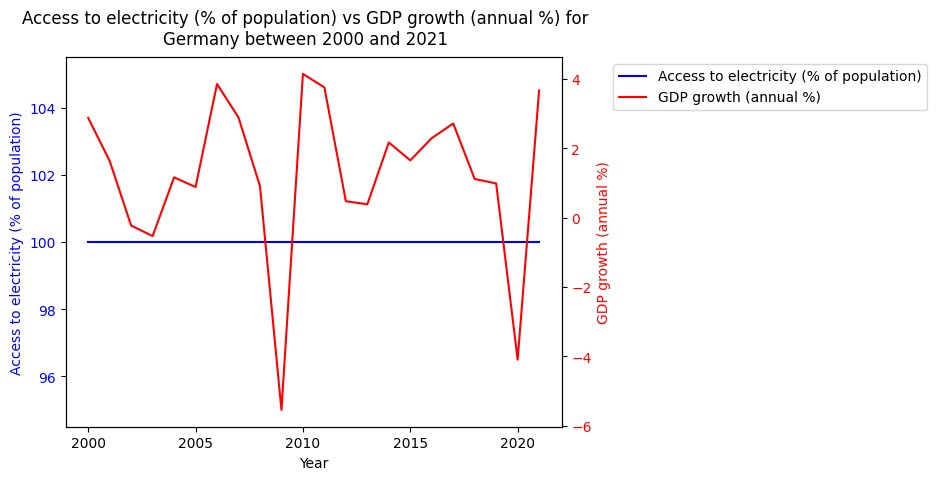

In [37]:
create_trend_plot_for_country(new_df,"Germany","Access to electricity (% of population)","GDP growth (annual %)")

## 4.3 Correlation Plot

Below plot shows how each feature correlates with the target feature. **Exports of goods and services (% of GDP)**,**Gross capital formation (% of GDP)** and **Inflation, consumer prices (annual %)** have positive correlation with our target feature **GDP growth (annual %)**. Whilst former two has a understandable relation later one Inflation forms a complicated relationship with GDP growth rate. A rising GDP growth means higher production rate which in turn reduces unemployment and could increase the wages of the working population. Increase wages rises the production costs and at the same time increases the purchasing power of a consumer. When purchasing power increases more demand arises which could inturn push the prices up. Eventually casuing higher inflation. All the central banks in every country try to keep the inflation rate at an optimum value. When there is higher inflation the institution increases the interest rates to lower the purchasing power of a consumer which in turn reduces the demand. This is the reason why rise in GDP growth does not have a linear rising relation with inflation rates.  More about it once can find here __[How GDP Growth Drives Inflation: Understanding the Economic Link](https://www.investopedia.com/ask/answers/112814/why-does-inflation-increase-gdp-growth.asp)__



**Individuals using the Internet (% of population)**,**Domestic credit to private sector by banks (% of GDP)**, **Life expectancy at birth, total (years)** and **Access to electricity (% of population)** are negatively correlated. But from the trend plots one could observe that there is no meaningful relation how these features affect the target variable. 


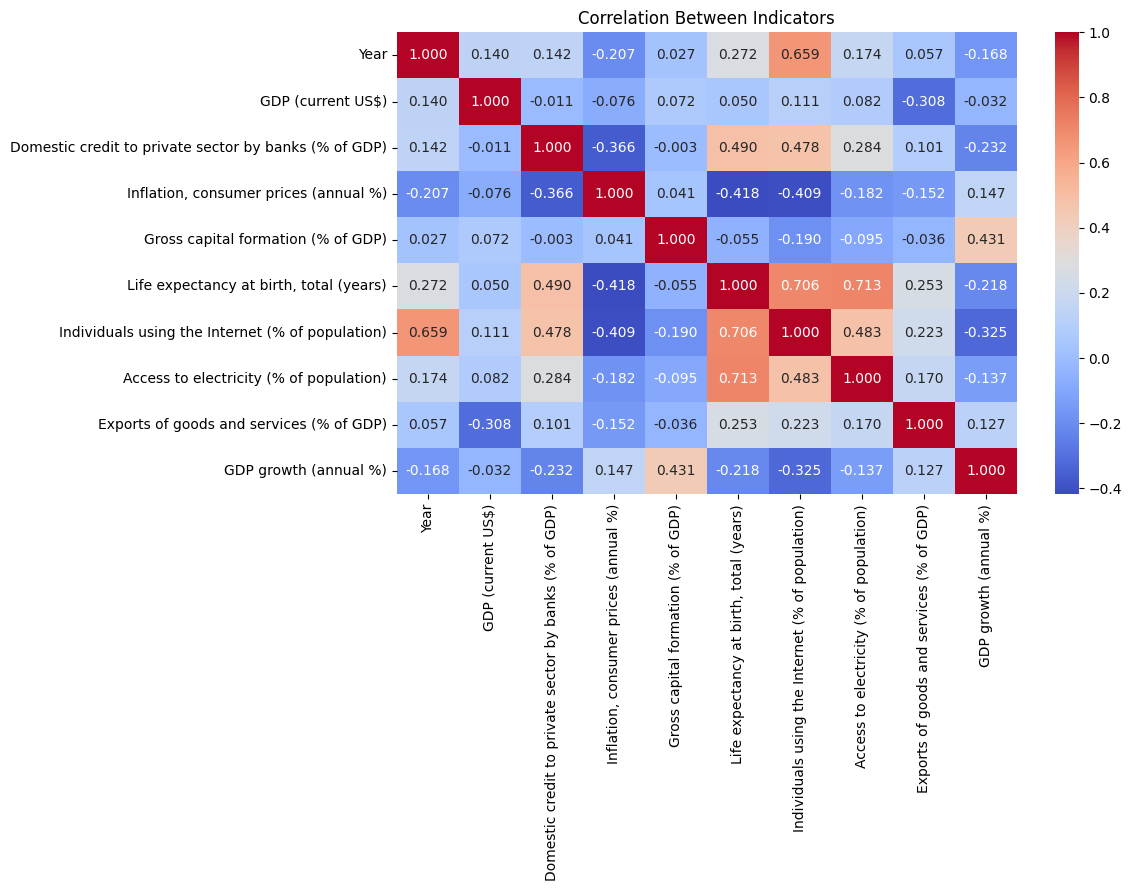

In [38]:
corr = new_df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Between Indicators")
plt.show()

In [39]:
# correlation matrix sorted by linear correlation with the target
corr["GDP growth (annual %)"].sort_values(ascending=False)

GDP growth (annual %)                                    1.000000
Gross capital formation (% of GDP)                       0.430809
Inflation, consumer prices (annual %)                    0.147080
Exports of goods and services (% of GDP)                 0.126788
GDP (current US$)                                       -0.031664
Access to electricity (% of population)                 -0.137438
Year                                                    -0.168323
Life expectancy at birth, total (years)                 -0.218011
Domestic credit to private sector by banks (% of GDP)   -0.231920
Individuals using the Internet (% of population)        -0.325194
Name: GDP growth (annual %), dtype: float64

## 4.4 Scatter Plot

Plotting the positively correlated features against GDP growth rate in scatter plot shows that Gross capital formation has a linear relation so is exports of goods and services.  Inflation on the other hand has some outliers which could be eliminated. Baring the outliers, inflation has a slightly linear relationship. 

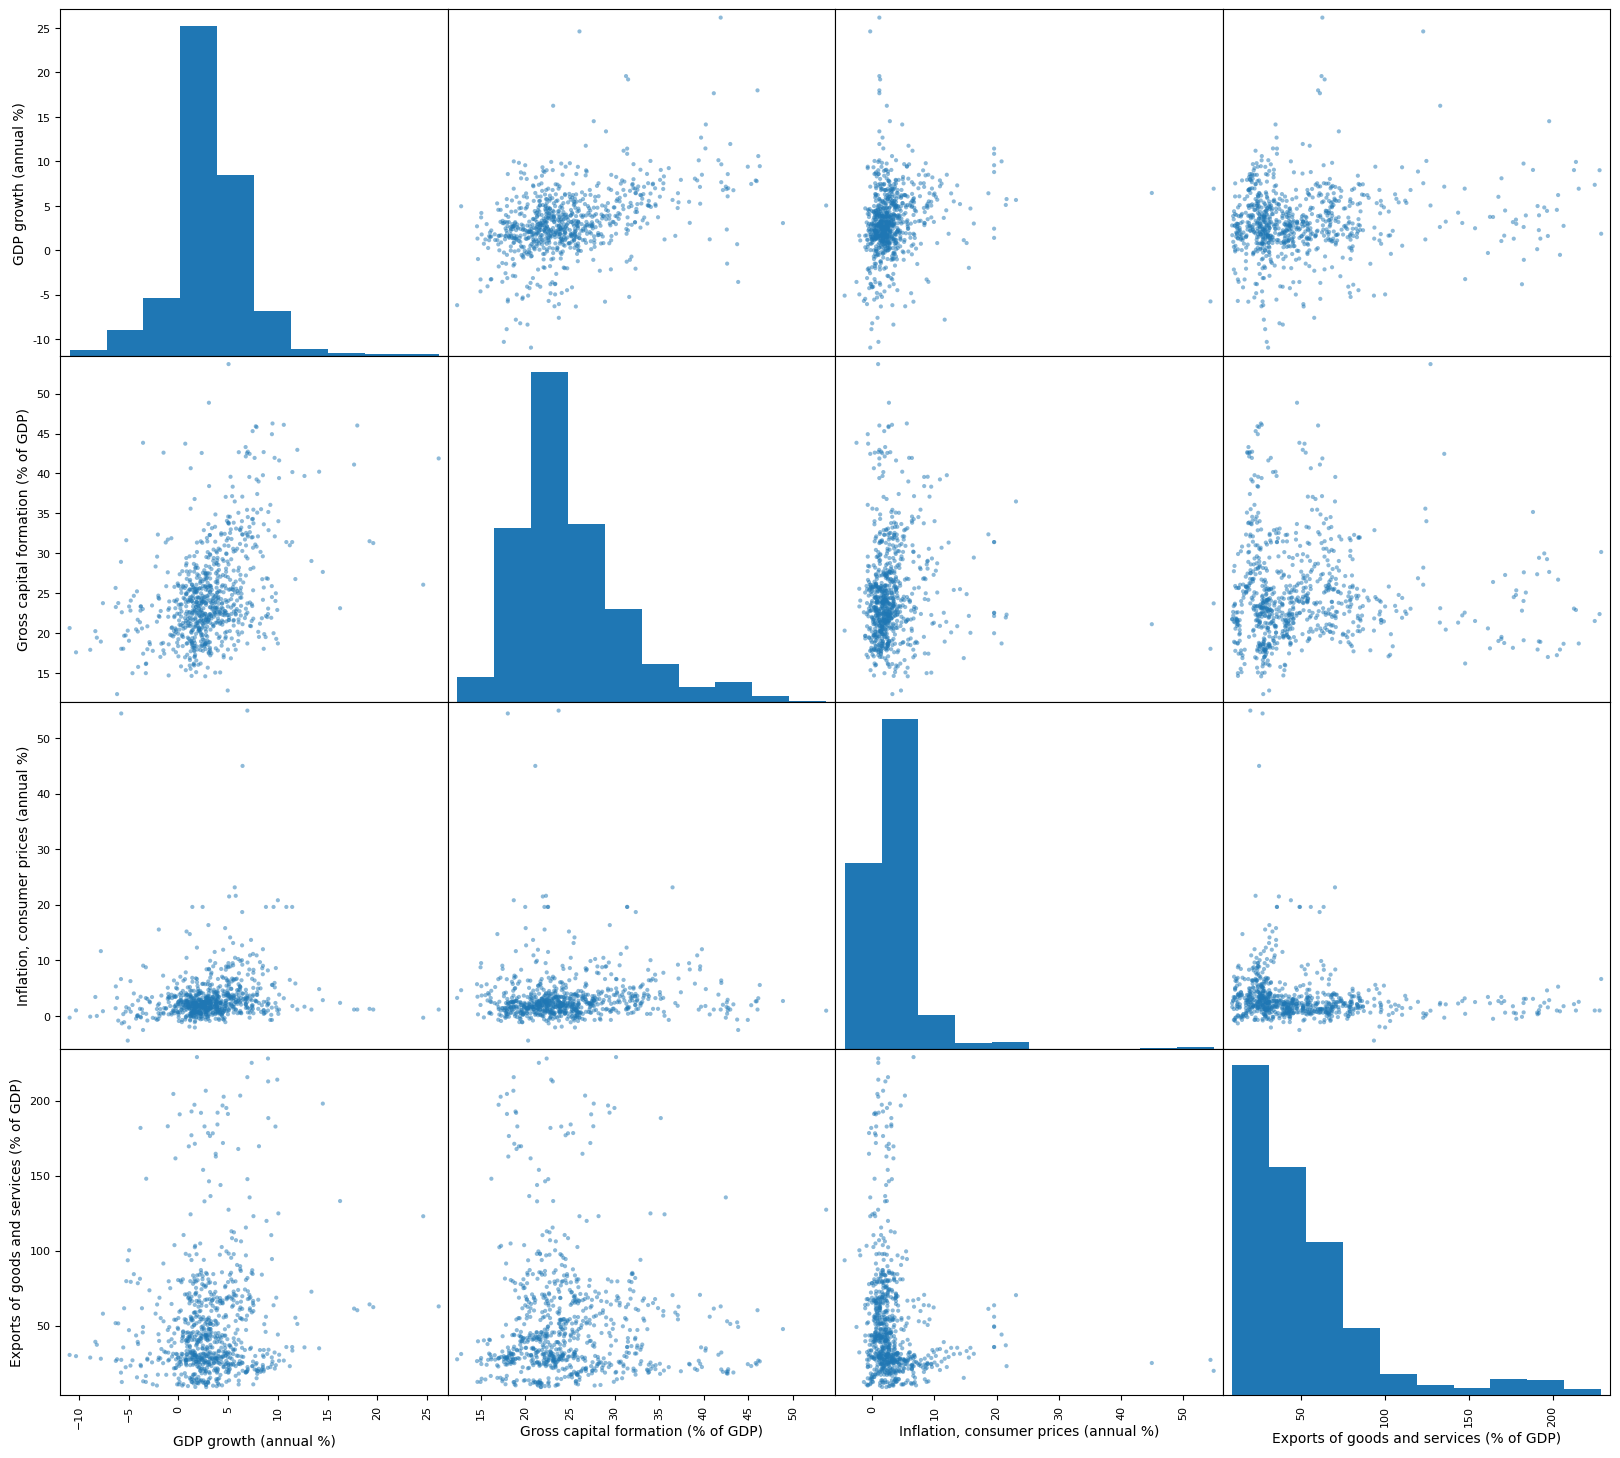

In [40]:
from pandas.plotting import scatter_matrix

features = ["GDP growth (annual %)", "Gross capital formation (% of GDP)", "Inflation, consumer prices (annual %)", "Exports of goods and services (% of GDP)"]

scatter_matrix(new_df[features], figsize=(20, 18))
plt.show()

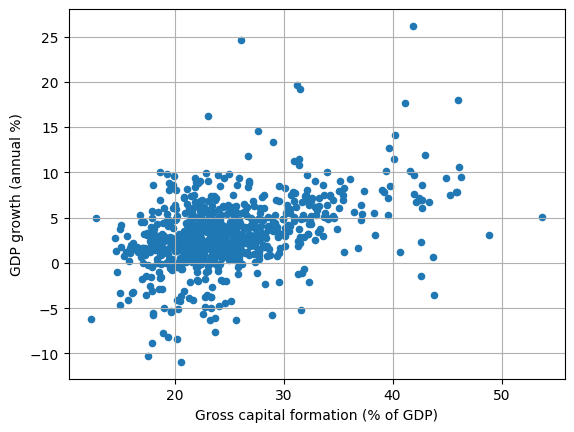

In [41]:
# Choosing here the most important feature and plotting it against the target
new_df.plot(kind="scatter", x="Gross capital formation (% of GDP)", y="GDP growth (annual %)", grid=True)
plt.show()

## 4.5 Finding Outliers using boxplot

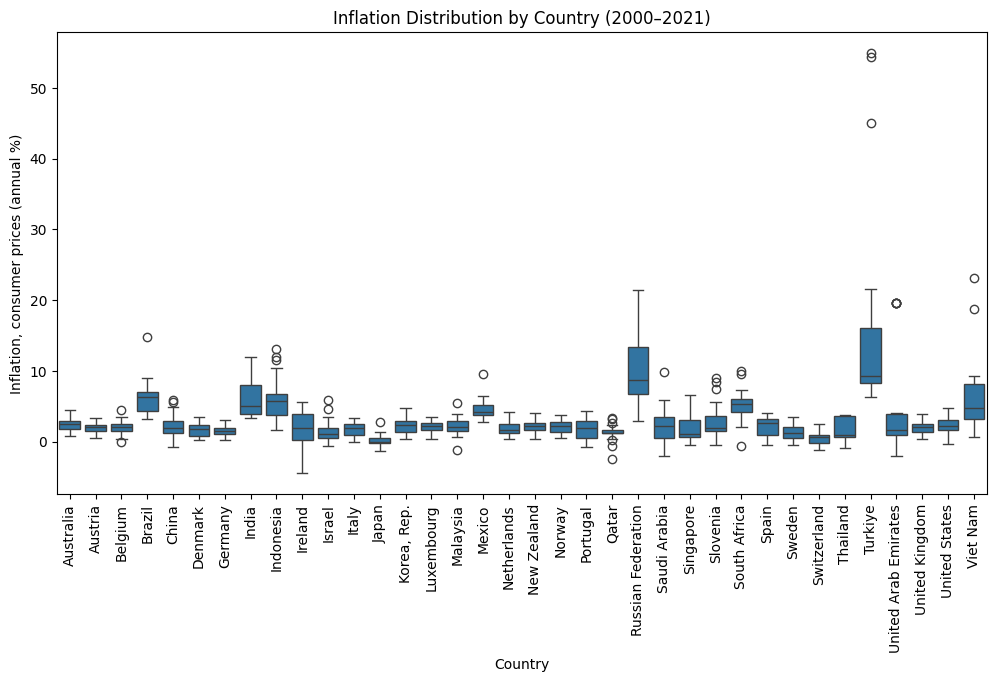

In [42]:
plt.figure(figsize=(12,6))
sns.boxplot(data=new_df, x="Country", y="Inflation, consumer prices (annual %)")
plt.xticks(rotation=90)
plt.title("Inflation Distribution by Country (2000–2021)")
plt.show()

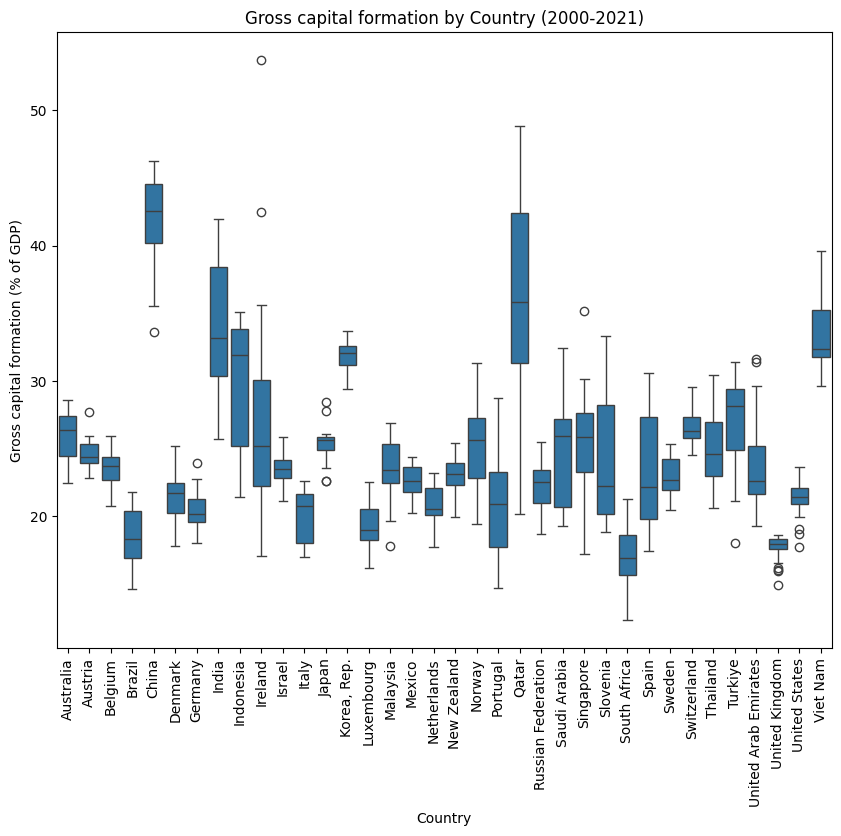

In [43]:
plt.figure(figsize=(10,8))
sns.boxplot(data=new_df, x="Country", y="Gross capital formation (% of GDP)")
plt.title("Gross capital formation by Country (2000-2021)")
plt.xticks(rotation=90)
plt.show()

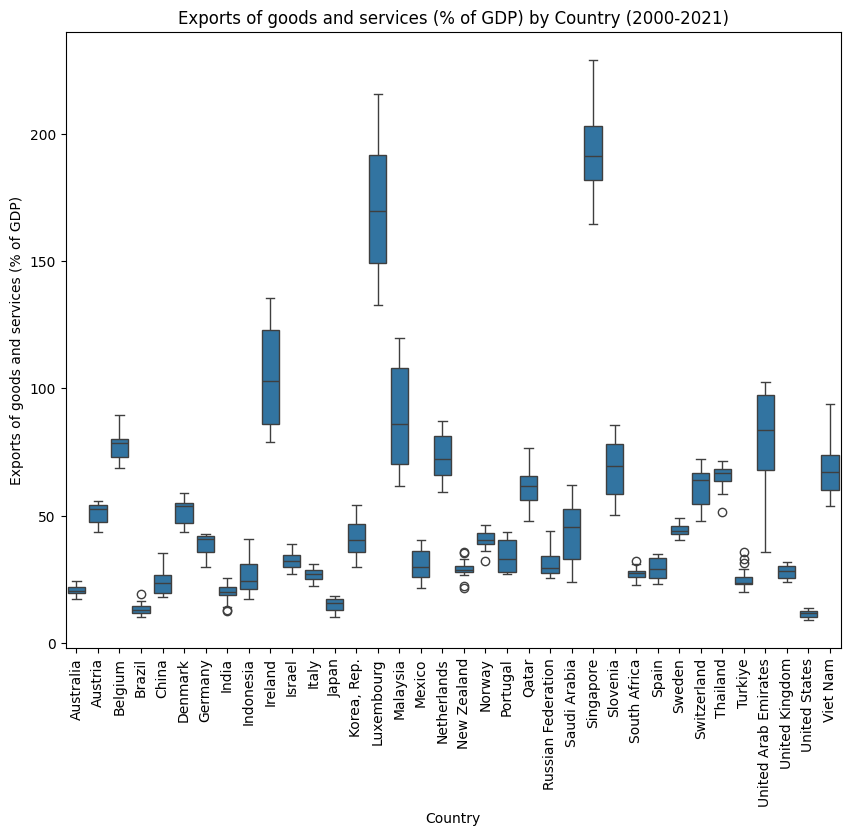

In [44]:
plt.figure(figsize=(10,8))
sns.boxplot(data=new_df, x="Country", y="Exports of goods and services (% of GDP)")
plt.title("Exports of goods and services (% of GDP) by Country (2000-2021)")
plt.xticks(rotation=90)
plt.show()

In [45]:
def outlier_plot(plot_df,features):
    plt.figure(figsize=(14,10))

    for i, var in enumerate(features, 1):
        plt.subplot(2, 2, i)  # 2x2 grid
        sns.boxplot(data=plot_df, x='Country', y=var)
        plt.title(var)
        plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

Based on the above box plots for **Inflation Distribution by Country (2000–2021)**, **Gross capital formation by Country (2000-2021)** and **Exports of goods and services (% of GDP) by Country (2000-2021)**, one could observe that there are outliers which are not explainable. 

For example: **Inflation, consumer prices (annual %)** of turkey seems abnormal which could affect the model prediction. Eventhough the values are real (Turkey had serious inflation in the past decade causing their currency to dilute against US dollar for the second time in this century), it could skew the results of the model.  

So it is best to tackle this by removing the outliers using Z-score with a threshold of Z=3. More about that one can read from Geeksforgeeks __[Detect and Remove the Outliers using Python](https://www.geeksforgeeks.org/data-science/detect-and-remove-the-outliers-using-python/)__

In [46]:
from scipy import stats

plot_variables =    [   "GDP growth (annual %)", "Gross capital formation (% of GDP)", 
                        "Inflation, consumer prices (annual %)", "Exports of goods and services (% of GDP)"
                    ]

feature_selection_for_outliers = [  "Gross capital formation (% of GDP)", "Inflation, consumer prices (annual %)", 
                                    "Exports of goods and services (% of GDP)"]

z = np.abs(stats.zscore(new_df[feature_selection_for_outliers]))

threshold_z = 3

outlier_indices = np.where(z > threshold_z)[0]
no_outliers_df = new_df.drop(outlier_indices)
print("Original DataFrame Shape:", new_df.shape)
print("DataFrame Shape after Removing Outliers:", no_outliers_df.shape)

Original DataFrame Shape: (792, 11)
DataFrame Shape after Removing Outliers: (737, 11)


### Outlier plot before removal of outliers:

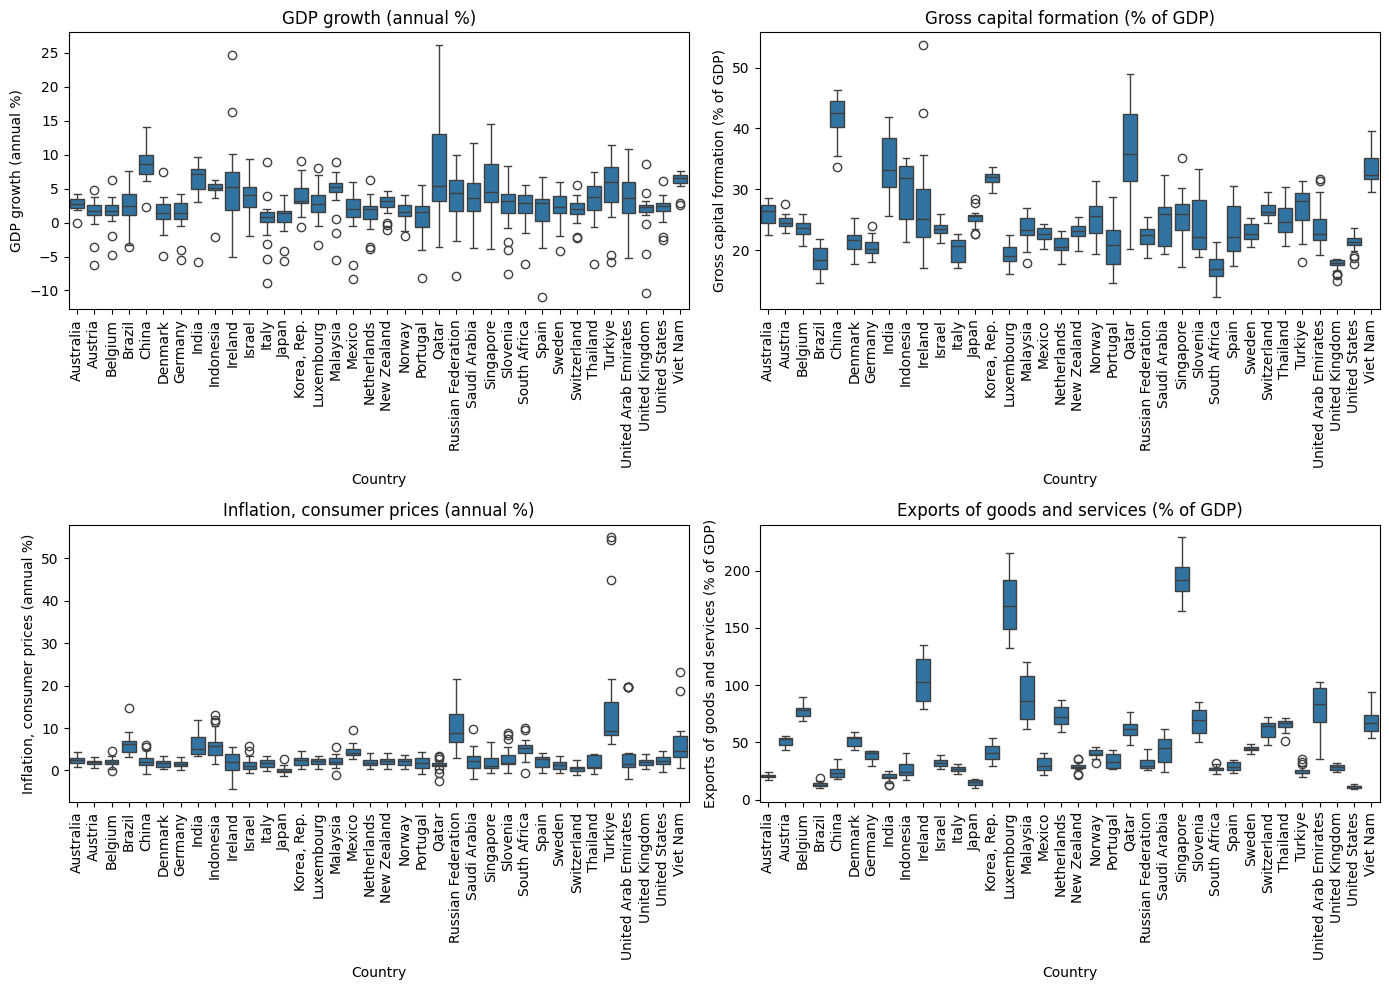

In [47]:
outlier_plot(new_df,plot_variables)

### Outlier plot after removal of outliers:

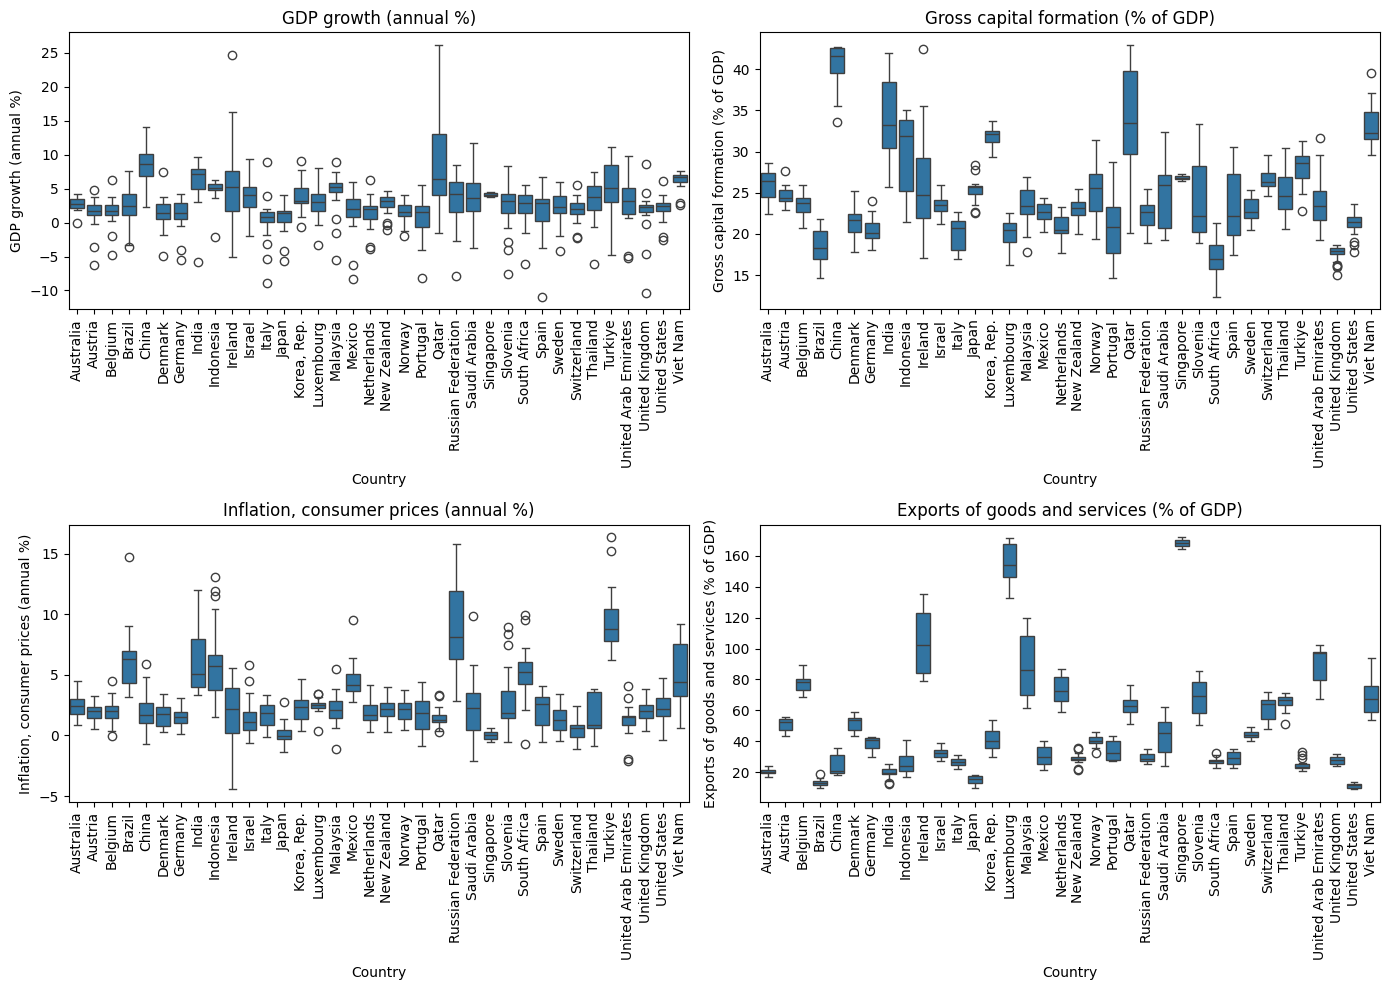

In [48]:
outlier_plot(no_outliers_df,plot_variables)

### Correlation plot after removing outliers:

After removing outliers, the correlation plot shows a slight increase for Inflation from 0.147 to 0.182 and for GCP from 0.431 to 0.446

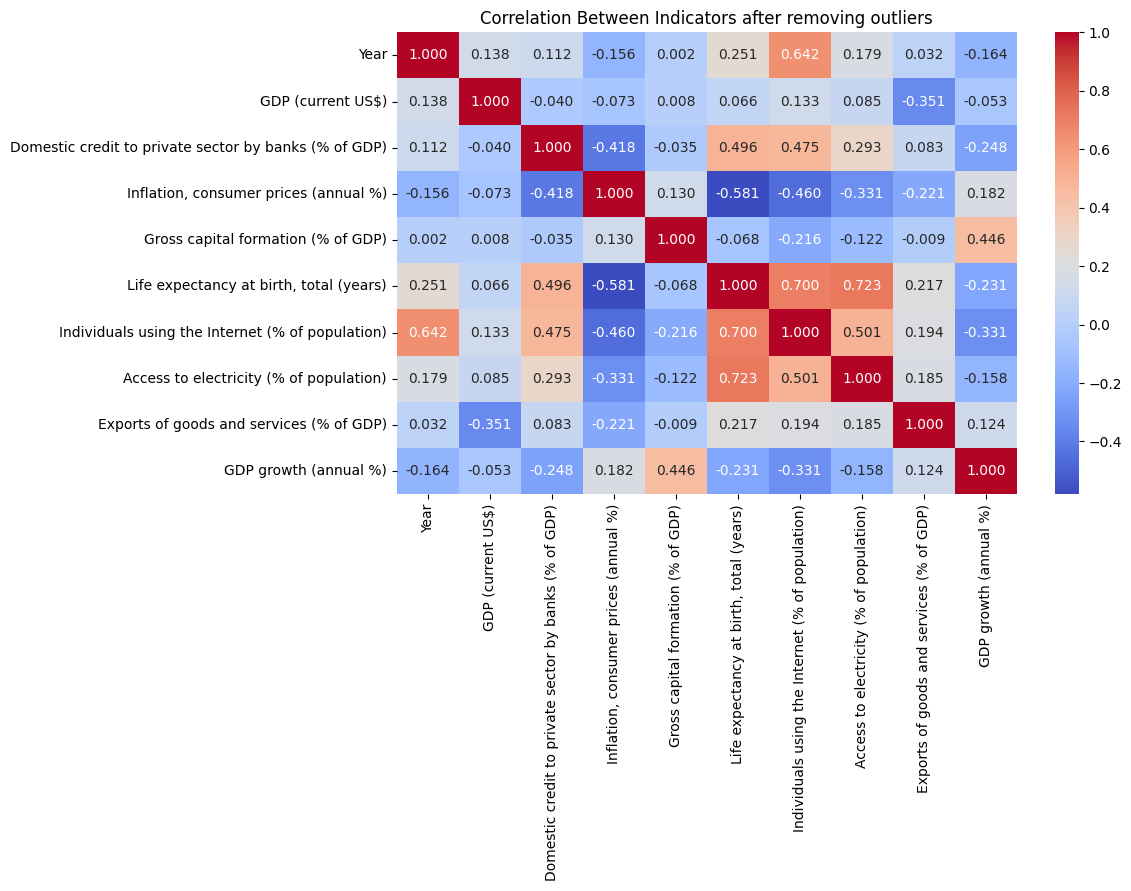

In [49]:
no_outliers_corr = no_outliers_df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(no_outliers_corr, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Between Indicators after removing outliers")
plt.show()

<div class="alert alert-block alert-info">
<b>Info:</b> 

Observing the dataset in general, we see that values have varied range. GDP in US Dollars are extremely high which could get more weightage from the model. In addition, many valalues are in percentage of GDP in US Dollars. To give equal weightage to all features, MinMax scaler was used.  

In Addition, most of the developed countries contribute more to the GDP in US dollars. To give equal weightage to all countries, MinMaxScaler was performed after grouping the rows on country. This kind of matches with test train split which is also made after grouping on countries. 

</div> 
      

        

In [50]:
from sklearn.preprocessing import MinMaxScaler

# List of features to scale (excluding 'Year' and 'Country')
features_to_scale = [
    'GDP (current US$)',
    'Domestic credit to private sector by banks (% of GDP)',
    'Inflation, consumer prices (annual %)',
    'Gross capital formation (% of GDP)',
    'Life expectancy at birth, total (years)',
    'Individuals using the Internet (% of population)',
    'Access to electricity (% of population)',
    'Exports of goods and services (% of GDP)'
]

# Create a copy of the DataFrame for scaled values
X_scaled = no_outliers_df.drop(['GDP growth (annual %)'],axis=1).copy()

# Apply MinMaxScaler per country
for country in no_outliers_df['Country'].unique():
    mask = no_outliers_df['Country'] == country
    scaler = MinMaxScaler()
    X_scaled.loc[mask, features_to_scale] = scaler.fit_transform(no_outliers_df.loc[mask, features_to_scale])


<div class="alert alert-block alert-success">
<b>Result:</b>
Dataframe after scaling
</div>

In [51]:
X_scaled.head()

,Country,Year,GDP (current US$),Domestic credit to private sector by banks (% of GDP),"Inflation, consumer prices (annual %)",Gross capital formation (% of GDP),"Life expectancy at birth, total (years)",Individuals using the Internet (% of population),Access to electricity (% of population),Exports of goods and services (% of GDP)
0,Australia,2000,0.030512,0.000000,1.000000,0.619008,0.000000,0.000000,0.0,0.318378
1,Australia,2001,0.000000,0.014945,0.986069,0.156315,0.098380,0.118153,0.0,0.713121
2,Australia,2002,0.013494,0.066799,0.591234,0.320568,0.172765,0.118153,0.0,0.509373
3,Australia,2003,0.073578,0.210409,0.522275,0.568247,0.247151,0.118153,0.0,0.270786
4,Australia,2004,0.196269,0.273477,0.414440,0.750685,0.308938,0.323480,0.0,0.000000


<div class="alert alert-block alert-success">
<b>Result:</b> 
Dataframe before scaling
</div>

In [52]:
new_df.head()

,Country,Year,GDP (current US$),Domestic credit to private sector by banks (% of GDP),"Inflation, consumer prices (annual %)",Gross capital formation (% of GDP),"Life expectancy at birth, total (years)",Individuals using the Internet (% of population),Access to electricity (% of population),Exports of goods and services (% of GDP),GDP growth (annual %)
0,Australia,2000,4.161678e+11,87.535179,4.457435,26.250464,79.234146,46.7561,100.0,19.390228,3.921503
1,Australia,2001,3.796293e+11,88.359079,4.407135,23.393064,79.634146,52.6893,100.0,22.152326,2.025106
2,Australia,2002,3.957887e+11,91.217703,2.981575,24.407426,79.936585,52.6893,100.0,20.726661,3.979586
3,Australia,2003,4.677391e+11,99.134711,2.732596,25.936985,80.239024,52.6893,100.0,19.057213,3.090762
4,Australia,2004,6.146600e+11,102.611546,2.343255,27.063647,80.490244,63.0000,100.0,17.162468,4.224285


In [53]:
print(f"Shape of X_scaled : {X_scaled.shape}")
print(f"Shape of new_df : {new_df.shape}")

Shape of X_scaled : (737, 10)
Shape of new_df : (792, 11)


In [54]:
def split_test_train_data(df,year):
    '''
    split_test_train_data(df)

    Splits a DataFrame containing economic indicators by country and year into training and testing datasets.

    Parameters:
    df (pd.DataFrame): A pandas DataFrame containing the following columns:
        - 'Country'
        - 'Year'
        - 'GDP (current US$)'
        - 'Domestic credit to private sector by banks (% of GDP)'
        - 'Inflation, consumer prices (annual %)'
        - 'Gross capital formation (% of GDP)'
        - 'Life expectancy at birth, total (years)'
        - 'Individuals using the Internet (% of population)'
        - 'Access to electricity (% of population)'
        - 'Exports of goods and services (% of GDP)'
        - 'GDP growth (annual %)' (target variable)
    year : Integer 
        - Variable to split the dataframe based on year

    The function splits the data such that:
        - Training data includes records with Year ≤ 2016
        - Testing data includes records with Year ≥ 2017

    Returns:
    tuple: A tuple containing the following:
        - X_train (pd.DataFrame): Features for training
        - X_test (pd.DataFrame): Features for testing
        - y_train (pd.Series): Target values for training
        - y_test (pd.Series): Target values for testing
    '''

    # Defining my feature columns and target column
    X_cols = [   'Country','Year','GDP (current US$)','Domestic credit to private sector by banks (% of GDP)','Inflation, consumer prices (annual %)','Gross capital formation (% of GDP)',
                'Life expectancy at birth, total (years)','Individuals using the Internet (% of population)','Access to electricity (% of population)',
                'Exports of goods and services (% of GDP)']
    target_col = 'GDP growth (annual %)'

    # Initializing empty dataframes 
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()

    # Loop over each country and split by year
    for country, group in df.groupby('Country'):
        train_part = group[group['Year'] <= year]
        test_part = group[group['Year'] > year]
        train_df = pd.concat([train_df, train_part])
        test_df = pd.concat([test_df, test_part])

    X_train = train_df[X_cols]
    y_train = train_df[target_col]

    X_test = test_df[X_cols]
    y_test = test_df[target_col]

    return X_train,X_test,y_train,y_test

<div class="alert alert-block alert-info">
<b>Info:</b> 
Test train split was performed coutry-wise and passing year as a splitter. So the predictions are made for each country for the future years. 
</div>

In [55]:
X_train,X_test,y_train,y_test = split_test_train_data(pd.concat([X_scaled,y],axis=1),2016)

In [56]:
X_train.shape

(571, 10)

In [57]:
X_test.shape

(166, 10)

# 5. Model fitting and evaluation using sklearn

From correlation plots and scatter plots, we see that **Gross Capital formation** has a linear relationship with **GDP Growth rate (in %)**. So proceeding with linear regression for prediction. 

## 5.1 Linear Regression

In [58]:
# Using Linear regression model from sklearn
linear_model = LinearRegression()
# Dropping categorical columns before fitting the model
linear_model.fit(X_train.drop(['Year','Country'],axis=1), y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


<div class="alert alert-block alert-info">
<b>Inference :</b> <br>
<br>
From the results of below metrics, rmse of train and test sets are around 3%. Our target variable is GDP Growth rate (in %) which usually is around 2-3% for developed economies. Having a rmse of 3% on train and test sets seems pretty high. 
<br>
<br>
Negative R^2 on test and training sets mean that the independent variables does not explain any variability in the dependent variable. Generally, the value should lie inbetween 0 and 1. Negative R^2 suggests that the model performs worse than the average fitted model.

</div>


In [59]:
y_pred_train = linear_model.predict(X_train.drop(['Year','Country'],axis=1))
y_pred_test = linear_model.predict(X_test.drop(['Year','Country'],axis=1))

mse_train = mean_squared_error(y_pred_train,y_train)
mse_test = mean_squared_error(y_pred_test,y_test)

r2_train = r2_score(y_pred_train,y_train)
r2_test = r2_score(y_pred_test,y_test)

rmse_train = root_mean_squared_error(y_pred_train,y_train)
rmse_test = root_mean_squared_error(y_pred_test,y_test)

print("MSE Train: ", mse_train)
print("MSE Test: ", mse_test)
print("R2 Train: ", r2_train)
print("R2 Test: ", r2_test)
print("RMSE Train: ", rmse_train)
print("RMSE Test: ", rmse_test)

MSE Train:  9.43455959193309
MSE Test:  15.4289791000945
R2 Train:  -2.255474158309097
R2 Test:  -10.771152372122405
RMSE Train:  3.0715728205486337
RMSE Test:  3.9279739179498763


In [60]:
# Reading linear regression model coefficients
coefficients = linear_model.coef_
feature_names = X_train.drop(['Year','Country'],axis=1).columns
for feature,coef in zip(feature_names,coefficients):
    print(f"Coefficient for {feature} : {coef}")

Coefficient for GDP (current US$) : -1.1892524521968972
Coefficient for Domestic credit to private sector by banks (% of GDP) : -1.9033340426668537
Coefficient for Inflation, consumer prices (annual %) : -1.3976110595737974
Coefficient for Gross capital formation (% of GDP) : 3.1264670627835245
Coefficient for Life expectancy at birth, total (years) : -0.48266875567836687
Coefficient for Individuals using the Internet (% of population) : -1.9866385596342646
Coefficient for Access to electricity (% of population) : 1.6216925289990998
Coefficient for Exports of goods and services (% of GDP) : 2.5094250497993924


In [61]:
def calc_rf_models(X_train,X_test,y_train,y_test,depth,estimator_count):
    '''
    Function to create random forest model and make predictions
    Parameters:
        X_train: Pandas dataframe
        X_test: Pandas dataframe
        y_train: Pandas Series
        y_test: Pandas Series
        depth: maximum depth parameter to be passed to Regressor model
        estimator_count: n_estimators to be passed to regressor model

    Returns:
        rf_regr: RandomForestRegressor()
    '''
    rf_regr = RandomForestRegressor(n_estimators=estimator_count,max_depth=depth, random_state=0)
    rf_regr.fit(X_train.drop(['Year','Country'],axis=1), y_train)

    y_pred_train_rf = rf_regr.predict(X_train.drop(['Year','Country'],axis=1))
    y_pred_test_rf = rf_regr.predict(X_test.drop(['Year','Country'],axis=1))

    mse_train_rf = mean_squared_error(y_pred_train_rf,y_train)
    mse_test_rf = mean_squared_error(y_pred_test_rf,y_test)

    r2_train_rf = r2_score(y_pred_train_rf,y_train)
    r2_test_rf = r2_score(y_pred_test_rf,y_test)

    rmse_train_rf = root_mean_squared_error(y_pred_train_rf,y_train)
    rmse_test_rf = root_mean_squared_error(y_pred_test_rf,y_test)

    print(f"MSE Train for max depth = {depth} and no. of estimators = {estimator_count}: ",mse_train_rf)
    print(f"MSE Test for max depth = {depth} and no. of estimators = {estimator_count}: ", mse_test_rf)
    print(f"R2 Train for max depth = {depth} and no. of estimators = {estimator_count}: ", r2_train_rf)
    print(f"R2 Test for max depth = {depth} and no. of estimators = {estimator_count}: ", r2_test_rf)
    print(f"RMSE Train for max depth = {depth} and no. of estimators = {estimator_count}: ", rmse_train_rf)
    print(f"RMSE Test for max depth = {depth} and no. of estimators = {estimator_count}: ", rmse_test_rf)

    return rf_regr

In [62]:
# Searching optimum hyper parameters for the model
list_for_depth = [2,4,8,16,32,64,128,256,512]
list_for_estimator = [1,3,5,10,15,20,50,100]
for i in list_for_depth:
    for j in list_for_estimator:
        print(f"************* Max Depth = {i} No. of estimators = {j} *************")
        calc_rf_models(X_train,X_test, y_train, y_test, i,j)
        print(f"*******************************************")

************* Max Depth = 2 No. of estimators = 1 *************
MSE Train for max depth = 2 and no. of estimators = 1:  10.532735629801676
MSE Test for max depth = 2 and no. of estimators = 1:  16.12200187790895
R2 Train for max depth = 2 and no. of estimators = 1:  -2.3911753686729025
R2 Test for max depth = 2 and no. of estimators = 1:  -11.619058252992463
RMSE Train for max depth = 2 and no. of estimators = 1:  3.2454176356521014
RMSE Test for max depth = 2 and no. of estimators = 1:  4.0152212738414494
*******************************************
************* Max Depth = 2 No. of estimators = 3 *************
MSE Train for max depth = 2 and no. of estimators = 3:  9.782779473173866
MSE Test for max depth = 2 and no. of estimators = 3:  15.220193677044048
R2 Train for max depth = 2 and no. of estimators = 3:  -4.102926713374643
R2 Test for max depth = 2 and no. of estimators = 3:  -35.392053627040305
RMSE Train for max depth = 2 and no. of estimators = 3:  3.1277435114110403
RMSE Tes

 9.506663627747981
MSE Test for max depth = 2 and no. of estimators = 100:  14.943949501488754
R2 Train for max depth = 2 and no. of estimators = 100:  -5.321326217063859
R2 Test for max depth = 2 and no. of estimators = 100:  -54.08921145999326
RMSE Train for max depth = 2 and no. of estimators = 100:  3.0832877951543836
RMSE Test for max depth = 2 and no. of estimators = 100:  3.8657404855329793
*******************************************
************* Max Depth = 4 No. of estimators = 1 *************
MSE Train for max depth = 4 and no. of estimators = 1:  9.550858702064911
MSE Test for max depth = 4 and no. of estimators = 1:  17.12797696046101
R2 Train for max depth = 4 and no. of estimators = 1:  -0.13363308997369128
R2 Test for max depth = 4 and no. of estimators = 1:  -4.14528697271009
RMSE Train for max depth = 4 and no. of estimators = 1:  3.0904463596808975
RMSE Test for max depth = 4 and no. of estimators = 1:  4.138596013198318
*******************************************
**

<div class="alert alert-block alert-success">
<b>Inference :</b> 

After Fine-tuning the hyperparameters, choosing a model which has low mean square error and root mean squasre error for both test and train sets. Considering our target variable is GDP prediction (in %) which is usually around 3% in most of the cases (for developed countries). And having a low RMSE on both test and train set should be one of the goal of the model. We could achieve the lowest with a **max_depth = 32** and **No. of estimators = 100**. Achieving a 3.82% RMSE on test set is still very high considering the nominal values of GDP lie around 0-3% for most of the developed countries. 
<br>
<br>
R^2 closer to 1 suggests that the model learnt the relationship between dependent and independent variable on the training set. But it performed bad on the test set which implies an overfitted model. 

</div>

In [63]:
num_estimators = 100
maximum_depth = 32
rf_rg_mod = calc_rf_models(X_train,X_test, y_train, y_test,maximum_depth,num_estimators)

MSE Train for max depth = 32 and no. of estimators = 100:  1.250450051662611
MSE Test for max depth = 32 and no. of estimators = 100:  14.65779127861235
R2 Train for max depth = 32 and no. of estimators = 100:  0.8261617484072528
R2 Test for max depth = 32 and no. of estimators = 100:  -9.487398412469409
RMSE Train for max depth = 32 and no. of estimators = 100:  1.1182352398590427
RMSE Test for max depth = 32 and no. of estimators = 100:  3.82854950060886


In [64]:
# Reading feature importances of the random forest model
feature_importances = rf_rg_mod.feature_importances_
feature_names = features_to_scale
for feature,coef in zip(feature_names,feature_importances):
    print(f"Feature importance for {feature} : {coef}")

Feature importance for GDP (current US$) : 0.0871546287364711
Feature importance for Domestic credit to private sector by banks (% of GDP) : 0.14542545764123885
Feature importance for Inflation, consumer prices (annual %) : 0.10930311550490976
Feature importance for Gross capital formation (% of GDP) : 0.1720567542291507
Feature importance for Life expectancy at birth, total (years) : 0.07808180687667653
Feature importance for Individuals using the Internet (% of population) : 0.20806426592199198
Feature importance for Access to electricity (% of population) : 0.06408252225268986
Feature importance for Exports of goods and services (% of GDP) : 0.13583144883687132


## 6. Model Interpretability using SHAP

### 6.1 Interpreting the Random forest model using SHAP

In [65]:
explainer = shap.TreeExplainer(rf_rg_mod, X_test.drop(['Year','Country'],axis=1))
shap_values_rf = explainer(X_scaled.drop(['Year','Country'],axis=1))

In [84]:
def shap_pdp_plot(model,shap_values,feature_to_plot,sample_ind):
    '''
    Function to plot shapley partial dependence plot

    Parameters:
    model: Model created using sklearn
    shap_values: shap values returned by explainer
    feature_to_plot: feature to be plotted in the Partial dependence plot
    sample_ind: index location in the test sample

    Returns: Nothing    
    '''
    shap.partial_dependence_plot(
        feature_to_plot,
        model.predict,
        X_test.drop(['Year','Country'],axis=1),
        model_expected_value=True,
        feature_expected_value=True,
        ice=False,
        shap_values=shap_values[sample_ind : sample_ind + 1, :],
    )

<div class="alert alert-block alert-info">
<b>Inference:</b> 
<br> 
<br>
Feature importance from shap values provide us a new dimension on how the model predicts the test sets. Shap values for random forest predict that the individuals using the internet is the most important feature to predict the GDP growth rate. Followed by domestic credit to private sector, gross capital formation and exports of goods and services. 
<br>
<br>
</div>

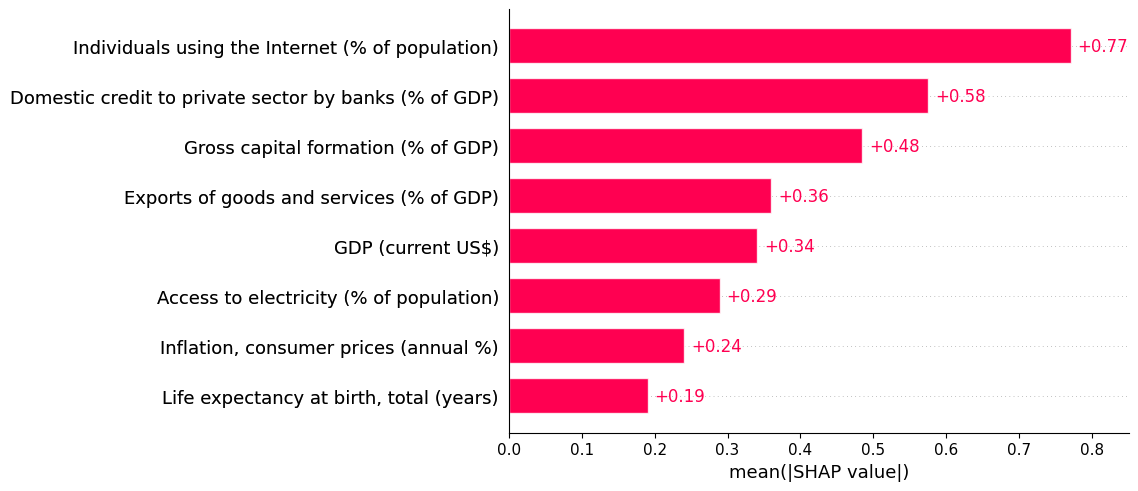

In [67]:
shap.plots.bar(shap_values_rf)

<div class="alert alert-block alert-info">
<b>Inference:</b> 
<br> 
<br>
Shap Partial dependence plot on Individuals using the the internet for random forest show that the feature is inversely related to the dependent variable. More the internet users lesser the GDP growth rate. This could mean that as countries progess toward developed economies the infrastructure develops and the number of internet users increase. Inching towards developed status warrants a lesser GDP growth rate. As we all know that developed economies have a less GDP growth. That could be the potential reason why the model predicted an inverse relation between the two variables.
<br>
<br>
</div>

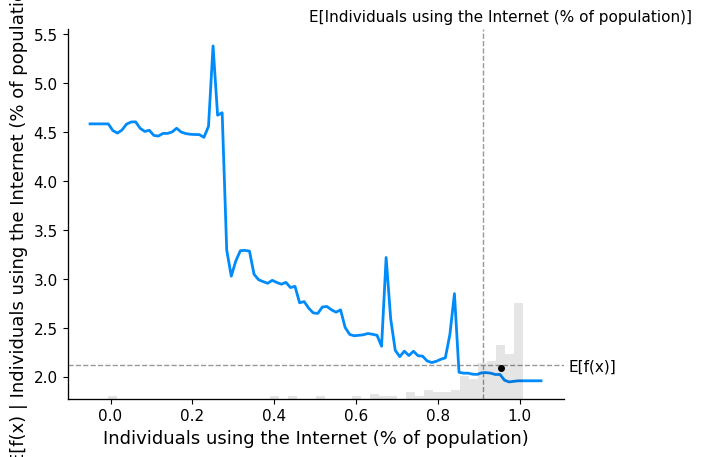

In [85]:
feature_for_shap = "Individuals using the Internet (% of population)"
shap_pdp_plot(rf_rg_mod,shap_values_rf,feature_for_shap,20)

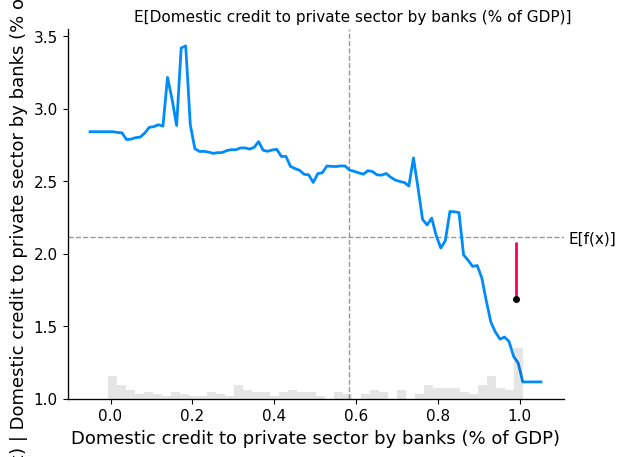

In [86]:
feature_for_shap = "Domestic credit to private sector by banks (% of GDP)"
shap_pdp_plot(rf_rg_mod,shap_values_rf,feature_for_shap,20)

<div class="alert alert-block alert-info">
<b>Inference:</b> 
<br> 
<br>
Gross capital formation and exports of goods & services have a direct relation with the target variable. 
<br>
<br>
</div>

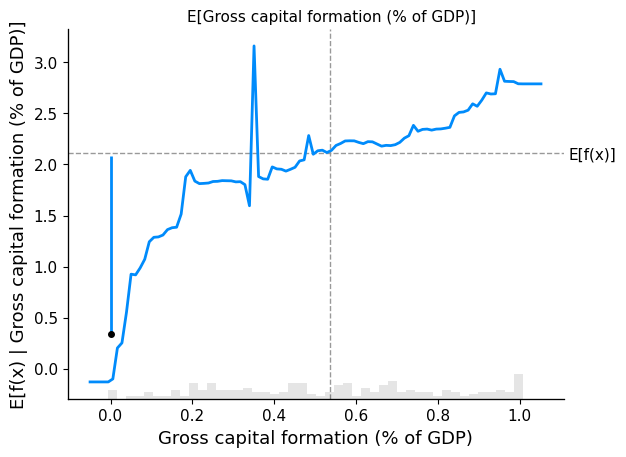

In [87]:
feature_for_shap = "Gross capital formation (% of GDP)"
shap_pdp_plot(rf_rg_mod,shap_values_rf,feature_for_shap,20)

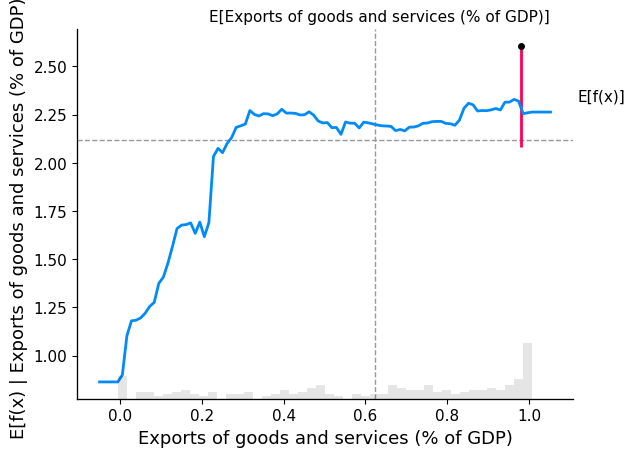

In [88]:
feature_for_shap = "Exports of goods and services (% of GDP)"
shap_pdp_plot(rf_rg_mod,shap_values_rf,feature_for_shap,20)

### 6.2 Interpreting the Linear Regression model using SHAP

In [72]:
explainer = shap.Explainer(linear_model.predict, X_test.drop(['Year','Country'],axis=1))
shap_values_linear = explainer(X_scaled.drop(['Year','Country'],axis=1))

<div class="alert alert-block alert-info">
<b>Inference:</b> 
<br> 
<br>
Interestingly, Linear regression has a different version of feature importance. From the scatter plots in EDA, we know that Gross capital formation had a linear relationship with target variable and from economic standpoint it would have a direct relation with GDP Growth rate. This was further ascertained by the SHAP values. Linear model also captured the correlation between individuals using the internet and the GDP growth rate. 
<br>
<br>
</div>

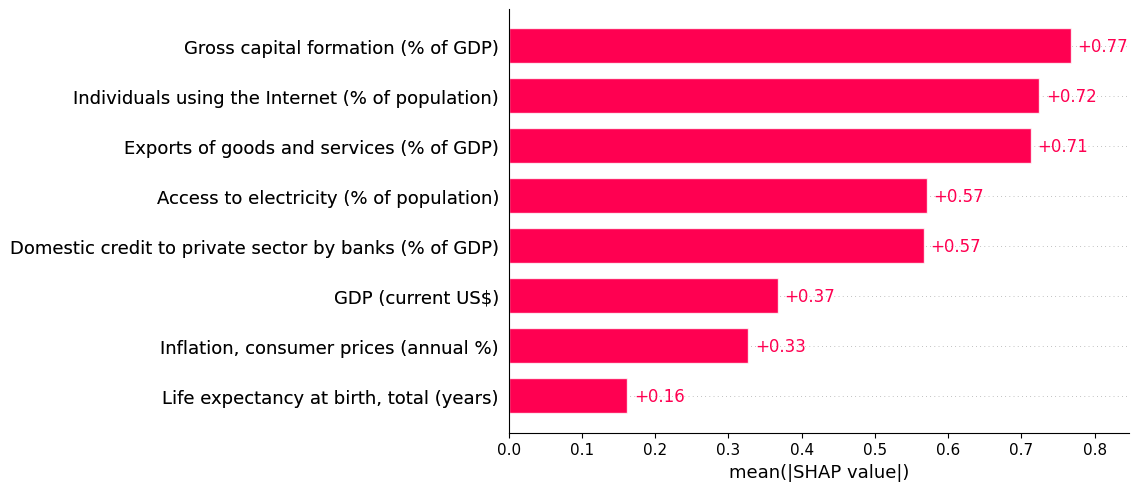

In [73]:
shap.plots.bar(shap_values_linear)

<div class="alert alert-block alert-info">
<b>Inference:</b> 
<br> 
<br>
Below we have the shap partial dependence plot for the most important features of linear regression model for the 21st sample. Gross capital formation and exports of goods & services have positive & higher effect on the model prediction. While domestic credit to private sector by banks has stronger negative effect. 
<br>
<br>
</div>

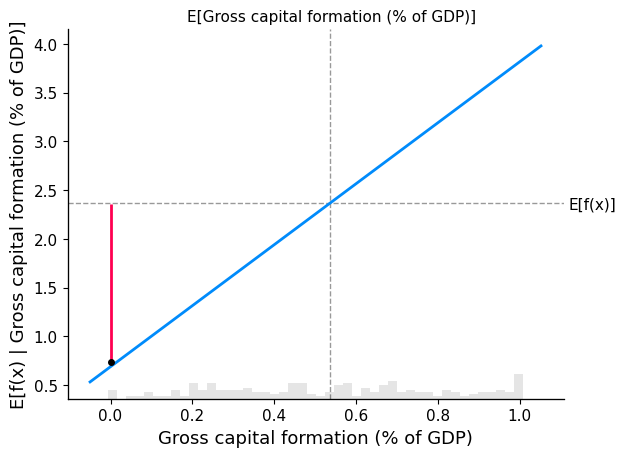

In [98]:
feature_for_shap = "Gross capital formation (% of GDP)"
shap_pdp_plot(linear_model,shap_values_linear,feature_for_shap,20)

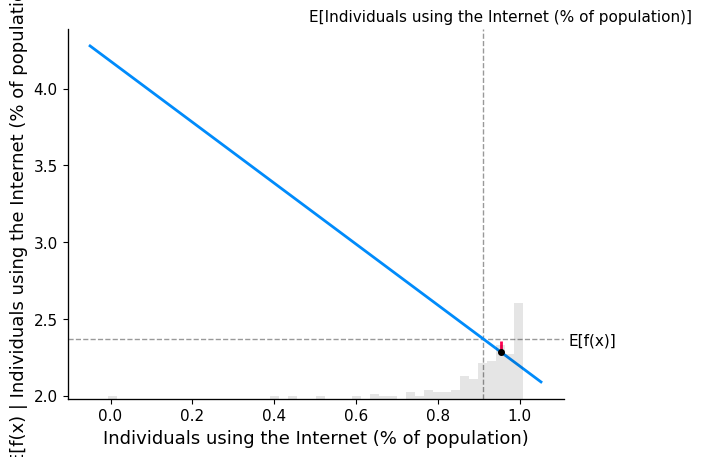

In [90]:
feature_for_shap = "Individuals using the Internet (% of population)"
shap_pdp_plot(linear_model,shap_values_linear,feature_for_shap,20)

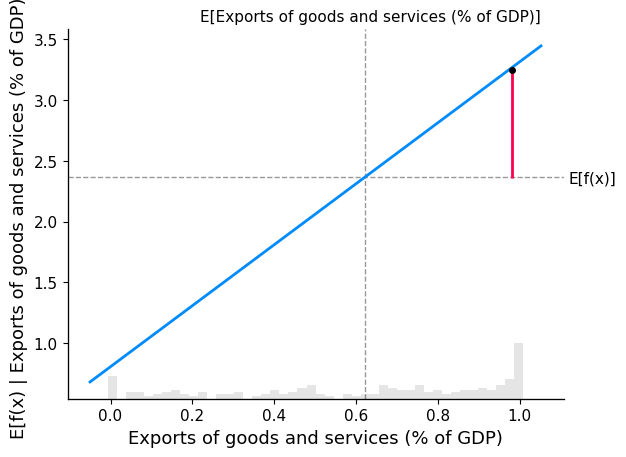

In [91]:
feature_for_shap = "Exports of goods and services (% of GDP)"
shap_pdp_plot(linear_model,shap_values_linear,feature_for_shap,20)

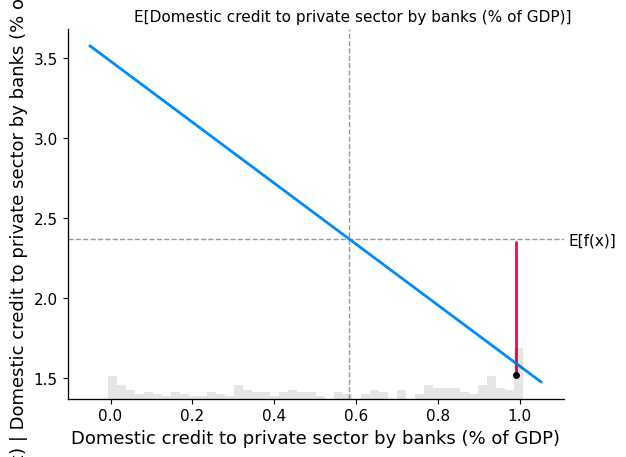

In [92]:
feature_for_shap = "Domestic credit to private sector by banks (% of GDP)"
shap_pdp_plot(linear_model,shap_values_linear,feature_for_shap,20)

<div class="alert alert-block alert-info">
<b>Info:</b><br>
<br>
<b>GDP Growth Prediction</b> for 26th sample in our test set using <b>Random forest regressor</b>> is 2.644<br>
<b>GDP Growth Prediction</b> for 100th sample in our test set using <b>Linear regression</b> is 3.455<br>
<b>Actual GDP Growth</b> for 100th sample in our test set is 1.860<br>
</div>

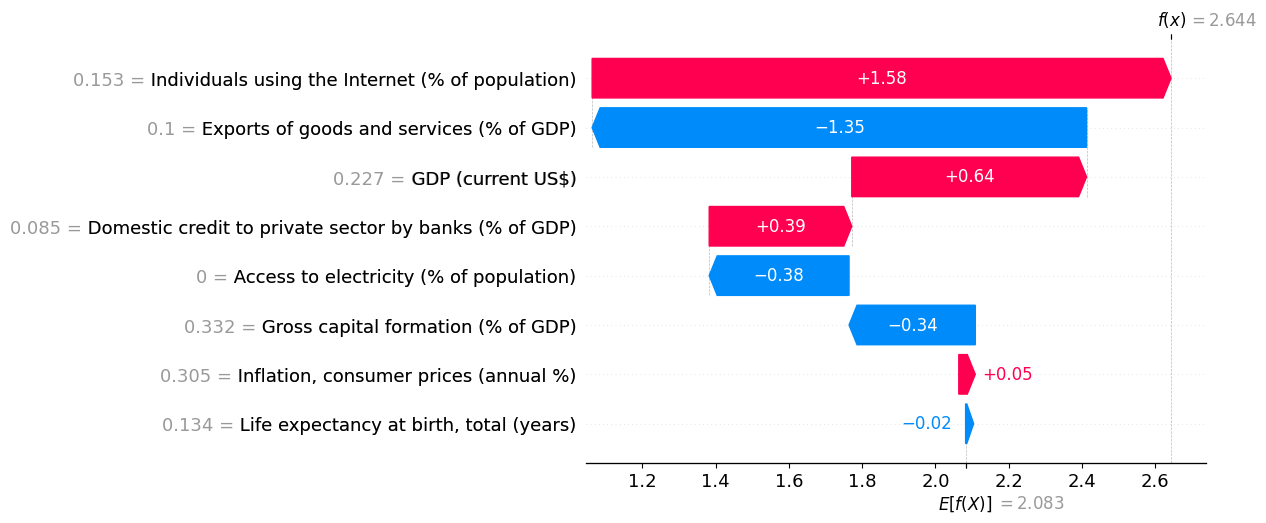

In [108]:
#Waterfall plot tells how a particular prediction was made taking into account all the features
shap.plots.waterfall(shap_values_rf[25], max_display=14)

In [104]:
#26th sample value from the test set 
y_test.iloc[25]

1.8600074900921

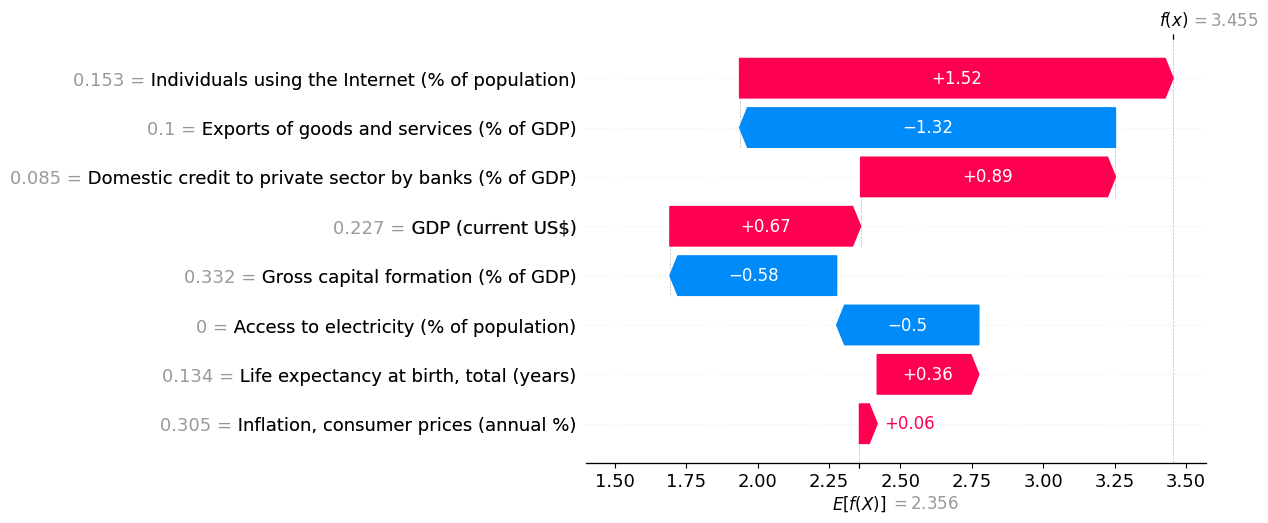

In [107]:
#Waterfall plot tells how a particular prediction was made taking into account all the features
shap.plots.waterfall(shap_values_linear[25], max_display=14)